# <span style="color:red"> Final Project </span>


# <span style="color:red"> I. Question 2 </span>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re 

In [17]:
import pandas as pd
import re
import unicodedata

# ---- CHANGE THIS IF NEEDED ----
season = "2024_25"
# --------------------------------

raw_input = """
Squad	MP	W	D	L	GF	GA	GD	Pts	Pts/MP	xG	xGA	xGD	xGD/90	Attendance	Top Team Scorer	Goalkeeper	Notes
1	Club Crest Barcelona	38	28	4	6	102	39	+63	88	2.32	91.5	41.9	+49.5	+1.30	45,953	Robert Lewandowski - 27	Iñaki Peña	→ Champions League via league finish
2	Club Crest Real Madrid	38	26	6	6	78	38	+40	84	2.21	75.3	42.8	+32.5	+0.86	69,807	Kylian Mbappé - 31	Thibaut Courtois	→ Champions League via league finish
3	Club Crest Atlético Madrid	38	22	10	6	68	30	+38	76	2.00	64.6	33.4	+31.2	+0.82	60,883	Alexander Sørloth - 20	Jan Oblak	→ Champions League via league finish
4	Club Crest Athletic Club	38	19	13	6	54	29	+25	70	1.84	53.0	37.8	+15.2	+0.40	48,420	Oihan Sancet - 15	Unai Simón	→ Champions League via league finish
5	Club Crest Villarreal	38	20	10	8	71	51	+20	70	1.84	64.8	44.4	+20.4	+0.54	18,266	Ayoze Pérez - 19	Diego Conde	→ Champions League via league finish
6	Club Crest Betis	38	16	12	10	57	50	+7	60	1.58	54.7	50.6	+4.1	+0.11	51,542	Isco - 9	Adrián	→ Europa League via league finish
7	Club Crest Celta Vigo	38	16	7	15	59	57	+2	55	1.45	54.2	43.4	+10.9	+0.29	21,504	Borja Iglesias - 11	Vicente Guaita	→ Europa League via league finish
8	Club Crest Rayo Vallecano	38	13	13	12	41	45	-4	52	1.37	45.4	49.0	-3.5	-0.09	12,908	Jorge de Frutos - 6	Augusto Batalla	→ Conference League via league finish
9	Club Crest Osasuna	38	12	16	10	48	52	-4	52	1.37	44.0	53.7	-9.7	-0.25	20,476	Ante Budimir - 21	Sergio Herrera	
10	Club Crest Mallorca	38	13	9	16	35	44	-9	48	1.26	38.8	46.8	-8.1	-0.21	18,502	Cyle Larin, Vedat Muriqi - 7	Dominik Greif	
11	Club Crest Real Sociedad	38	13	7	18	35	46	-11	46	1.21	42.5	43.9	-1.4	-0.04	29,877	Mikel Oyarzabal - 9	Álex Remiro	
12	Club Crest Valencia	38	11	13	14	44	54	-10	46	1.21	43.3	51.9	-8.6	-0.23	43,042	Hugo Duro - 11	Giorgi Mamardashvili	
13	Club Crest Getafe	38	11	9	18	34	39	-5	42	1.11	36.8	46.2	-9.4	-0.25	11,469	Mauro Arambarri - 10	David Soria	
14	Club Crest Espanyol	38	11	9	18	40	51	-11	42	1.11	34.4	53.9	-19.5	-0.51	25,640	Javi Puado - 12	Joan García	
15	Club Crest Alavés	38	10	12	16	38	48	-10	42	1.11	42.8	47.0	-4.2	-0.11	17,318	Kiké - 13	Antonio Sivera	
16	Club Crest Girona	38	11	8	19	44	60	-16	41	1.08	42.5	50.4	-8.0	-0.21	11,657	Cristhian Stuani - 11	Paulo Gazzaniga	
17	Club Crest Sevilla	38	10	11	17	42	55	-13	41	1.08	42.7	47.4	-4.7	-0.12	35,619	Dodi Lukebakio - 11	Ørjan Nyland	
18	Club Crest Leganés	38	9	13	16	39	56	-17	40	1.05	36.0	59.4	-23.4	-0.62	11,135	Dani Raba - 8	Marko Dmitrović	Relegated
19	Club Crest Las Palmas	38	8	8	22	40	61	-21	32	0.84	36.3	66.8	-30.5	-0.80	23,010	Fábio Silva - 10	Jasper Cillessen	Relegated
20	Club Crest Valladolid	38	4	4	30	26	90	-64	16	0.42	34.6	67.6	-33.0	-0.87	19,831	Mamadou Sylla - 
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2024_25)

    Rank            Squad  MP   W   D   L   GF  GA  GD  Pts   Season
0      1        Barcelona  38  28   4   6  102  39  63   88  2024_25
1      2      Real Madrid  38  26   6   6   78  38  40   84  2024_25
2      3  Atlético Madrid  38  22  10   6   68  30  38   76  2024_25
3      4         Athletic  38  19  13   6   54  29  25   70  2024_25
4      5       Villarreal  38  20  10   8   71  51  20   70  2024_25
5      6            Betis  38  16  12  10   57  50   7   60  2024_25
6      7       Celta Vigo  38  16   7  15   59  57   2   55  2024_25
7      8   Rayo Vallecano  38  13  13  12   41  45  -4   52  2024_25
8      9          Osasuna  38  12  16  10   48  52  -4   52  2024_25
9     10         Mallorca  38  13   9  16   35  44  -9   48  2024_25
10    11    Real Sociedad  38  13   7  18   35  46 -11   46  2024_25
11    12         Valencia  38  11  13  14   44  54 -10   46  2024_25
12    13           Getafe  38  11   9  18   34  39  -5   42  2024_25
13    14         Espanyol  38  11 

In [18]:
import pandas as pd
import re
import unicodedata

# ---- CHANGE THIS IF NEEDED ----
season = "2023_24"
# --------------------------------

raw_input = """
k	Squad	MP	W	D	L	GF	GA	GD	Pts	Pts/MP	xG	xGA	xGD	xGD/90	Attendance	Top Team Scorer	Goalkeeper	Notes
1	Club Crest Real Madrid	38	29	8	1	87	26	+61	95	2.50	68.8	35.4	+33.4	+0.88	72,061	Jude Bellingham - 19	Andriy Lunin	→ Champions League via league finish
2	Club Crest Barcelona	38	26	7	5	79	44	+35	85	2.24	77.6	41.6	+35.9	+0.94	39,846	Robert Lewandowski - 19	Marc-André ter Stegen	→ Champions League via league finish
3	Club Crest Girona	38	25	6	7	85	46	+39	81	2.13	70.8	54.3	+16.5	+0.43	12,520	Artem Dovbyk - 24	Paulo Gazzaniga	→ Champions League via league finish
4	Club Crest Atlético Madrid	38	24	4	10	70	43	+27	76	2.00	62.4	39.5	+23.0	+0.60	59,121	Antoine Griezmann - 16	Jan Oblak	→ Champions League via league finish
5	Club Crest Athletic Club	38	19	11	8	61	37	+24	68	1.79	52.7	41.3	+11.4	+0.30	46,112	Gorka Guruzeta - 14	Unai Simón	→ Europa League via cup win
6	Club Crest Real Sociedad	38	16	12	10	51	39	+12	60	1.58	44.9	41.3	+3.6	+0.10	31,710	Mikel Oyarzabal - 9	Álex Remiro	→ Europa League via league finish
7	Club Crest Betis	38	14	15	9	48	45	+3	57	1.50	43.9	50.2	-6.3	-0.17	51,259	Willian José - 10	Rui Silva	→ Conference League via league finish
8	Club Crest Villarreal	38	14	11	13	65	65	0	53	1.39	55.6	58.7	-3.2	-0.08	17,957	Alexander Sørloth - 23	Filip Jørgensen	
9	Club Crest Valencia	38	13	10	15	40	45	-5	49	1.29	43.1	47.6	-4.5	-0.12	43,420	Hugo Duro - 13	Giorgi Mamardashvili	
10	Club Crest Alavés	38	12	10	16	36	46	-10	46	1.21	46.2	44.7	+1.5	+0.04	17,391	Samu Omorodion - 8	Antonio Sivera	
11	Club Crest Osasuna	38	12	9	17	45	56	-11	45	1.18	40.5	49.9	-9.4	-0.25	19,703	Ante Budimir - 17	Sergio Herrera	
12	Club Crest Getafe	38	10	13	15	42	54	-12	43	1.13	45.7	53.8	-8.1	-0.21	11,456	Borja Mayoral - 15	David Soria	
13	Club Crest Celta Vigo	38	10	11	17	46	57	-11	41	1.08	50.7	54.6	-3.8	-0.10	20,039	Jørgen Strand Larsen - 13	Vicente Guaita	
14	Club Crest Sevilla	38	10	11	17	48	54	-6	41	1.08	44.9	55.9	-11.0	-0.29	34,984	Youssef En-Nesyri - 16	Ørjan Nyland	
15	Club Crest Mallorca	38	8	16	14	33	44	-11	40	1.05	40.5	42.9	-2.5	-0.06	17,767	Vedat Muriqi - 7	Predrag Rajković	
16	Club Crest Las Palmas	38	10	10	18	33	47	-14	40	1.05	33.2	56.6	-23.5	-0.62	25,041	Kirian Rodríguez - 6	Álvaro Vallés	
17	Club Crest Rayo Vallecano	38	8	14	16	29	48	-19	38	1.00	42.3	44.6	-2.3	-0.06	12,749	Álvaro García - 6	Stole Dimitrievski	
18	Club Crest Cádiz	38	6	15	17	26	55	-29	33	0.87	36.0	52.3	-16.3	-0.43	18,016	Chris Ramos - 5	Jeremías Ledesma	Relegated
19	Club Crest Almería	38	3	12	23	43	75	-32	21	0.55	48.7	61.6	-12.9	-0.34	12,893	Sergio Arribas - 9	Luís Maximiano	Relegated
20	Club Crest Granada	38	4	9	25	38	79	-41	21	0.55	42.6	64.2	-21.6	-0.57	16,350	Myrto Uzuni - 11	Augusto Bata
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2023_24)

    Rank            Squad  MP   W   D   L  GF  GA  GD  Pts   Season
0      1      Real Madrid  38  29   8   1  87  26  61   95  2023_24
1      2        Barcelona  38  26   7   5  79  44  35   85  2023_24
2      3           Girona  38  25   6   7  85  46  39   81  2023_24
3      4  Atlético Madrid  38  24   4  10  70  43  27   76  2023_24
4      5         Athletic  38  19  11   8  61  37  24   68  2023_24
5      6    Real Sociedad  38  16  12  10  51  39  12   60  2023_24
6      7            Betis  38  14  15   9  48  45   3   57  2023_24
7      8       Villarreal  38  14  11  13  65  65   0   53  2023_24
8      9         Valencia  38  13  10  15  40  45  -5   49  2023_24
9     10           Alavés  38  12  10  16  36  46 -10   46  2023_24
10    11          Osasuna  38  12   9  17  45  56 -11   45  2023_24
11    12           Getafe  38  10  13  15  42  54 -12   43  2023_24
12    13       Celta Vigo  38  10  11  17  46  57 -11   41  2023_24
13    14          Sevilla  38  10  11  17  48  5

In [19]:
import pandas as pd
import re
import unicodedata

# ---- CHANGE THIS IF NEEDED ----
season = "2022_23"
# --------------------------------

raw_input = """
	Squad	MP	W	D	L	GF	GA	GD	Pts	Pts/MP	xG	xGA	xGD	xGD/90	Attendance	Top Team Scorer	Goalkeeper	Notes
1	Club Crest Barcelona	38	28	4	6	70	20	+50	88	2.32	75.5	33.2	+42.3	+1.11	83,498	Robert Lewandowski - 23	Marc-André ter Stegen	→ Champions League via league finish
2	Club Crest Real Madrid	38	24	6	8	75	36	+39	78	2.05	75.5	38.9	+36.6	+0.96	56,649	Karim Benzema - 19	Thibaut Courtois	→ Champions League via league finish
3	Club Crest Atlético Madrid	38	23	8	7	70	33	+37	77	2.03	61.9	41.1	+20.8	+0.55	55,800	Antoine Griezmann - 15	Jan Oblak	→ Champions League via league finish
4	Club Crest Real Sociedad	38	21	8	9	51	35	+16	71	1.87	52.9	33.0	+19.8	+0.52	32,189	Alexander Sørloth - 12	Álex Remiro	→ Champions League via league finish
5	Club Crest Villarreal	38	19	7	12	59	40	+19	64	1.68	61.6	49.9	+11.8	+0.31	16,406	Nicolas Jackson - 12	Pepe Reina	→ Europa League via league finish
6	Club Crest Betis	38	17	9	12	46	41	+5	60	1.58	51.3	50.0	+1.3	+0.03	49,635	Borja Iglesias - 15	Rui Silva	→ Europa League via league finish
7	Club Crest Osasuna	38	15	8	15	37	42	-5	53	1.39	39.8	45.7	-5.9	-0.15	19,655	Ante Budimir, Ezequiel Ávila - 8	Aitor Fernández	→ Conference League via league finish
8	Club Crest Athletic Club	38	14	9	15	47	43	+4	51	1.34	54.2	36.9	+17.3	+0.46	43,488	Iñaki Williams, Oihan Sancet - 10	Unai Simón	
9	Club Crest Mallorca	38	14	8	16	37	43	-6	50	1.32	35.2	46.4	-11.2	-0.30	14,799	Vedat Muriqi - 15	Predrag Rajković	
10	Club Crest Girona	38	13	10	15	58	55	+3	49	1.29	50.6	54.9	-4.3	-0.11	11,471	Valentín Castellanos - 13	Paulo Gazzaniga	
11	Club Crest Rayo Vallecano	38	13	10	15	45	53	-8	49	1.29	43.9	50.3	-6.4	-0.17	12,525	Isaac Palazón Camacho - 9	Stole Dimitrievski	
12	Club Crest Sevilla	38	13	10	15	47	54	-7	49	1.29	46.3	54.2	-7.9	-0.21	35,566	Youssef En-Nesyri - 8	Yassine Bounou	
13	Club Crest Celta Vigo	38	11	10	17	43	53	-10	43	1.13	42.6	45.4	-2.8	-0.07	14,425	Iago Aspas - 12	Agustín Marchesín, Iván Villar	
14	Club Crest Cádiz	38	10	12	16	30	53	-23	42	1.11	41.5	61.6	-20.1	-0.53	17,741	Theo Bongonda, Gonzalo Escalante - 4	Jeremías Ledesma	
15	Club Crest Getafe	38	10	12	16	34	45	-11	42	1.11	36.7	46.0	-9.4	-0.25	11,592	Enes Ünal - 14	David Soria	
16	Club Crest Valencia	38	11	9	18	42	45	-3	42	1.11	49.3	43.5	+5.8	+0.15	40,602	Samuel Lino, Justin Kluivert - 6	Giorgi Mamardashvili	
17	Club Crest Almería	38	11	8	19	49	65	-16	41	1.08	45.5	62.5	-17.0	-0.45	12,961	El Bilal Touré - 7	Fernando	
18	Club Crest Valladolid	38	11	7	20	33	63	-30	40	1.05	38.5	65.2	-26.6	-0.70	20,943	Cyle Larin - 8	Jordi Masip	Relegated
19	Club Crest Espanyol	38	8	13	17	52	69	-17	37	0.97	48.3	59.8	-11.5	-0.30	21,601	Joselu - 16	Fernando Pacheco	Relegated
20	Club Crest Elche	38	5	10	23	30	67	-37	25	0.66	37.5	70.0	-32.6	-0.86	19,875	Lucas Boyé - 7	Édgar B
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2022_23)

    Rank            Squad  MP   W   D   L  GF  GA  GD  Pts   Season
0      1        Barcelona  38  28   4   6  70  20  50   88  2022_23
1      2      Real Madrid  38  24   6   8  75  36  39   78  2022_23
2      3  Atlético Madrid  38  23   8   7  70  33  37   77  2022_23
3      4    Real Sociedad  38  21   8   9  51  35  16   71  2022_23
4      5       Villarreal  38  19   7  12  59  40  19   64  2022_23
5      6            Betis  38  17   9  12  46  41   5   60  2022_23
6      7          Osasuna  38  15   8  15  37  42  -5   53  2022_23
7      8         Athletic  38  14   9  15  47  43   4   51  2022_23
8      9         Mallorca  38  14   8  16  37  43  -6   50  2022_23
9     10           Girona  38  13  10  15  58  55   3   49  2022_23
10    11   Rayo Vallecano  38  13  10  15  45  53  -8   49  2022_23
11    12          Sevilla  38  13  10  15  47  54  -7   49  2022_23
12    13       Celta Vigo  38  11  10  17  43  53 -10   43  2022_23
13    14            Cádiz  38  10  12  16  30  5

In [20]:

# ---- CHANGE THIS IF NEEDED ----
season = "2021_22"
# --------------------------------

raw_input = """
	Squad	MP	W	D	L	GF	GA	GD	Pts	Pts/MP	xG	xGA	xGD	xGD/90	Attendance	Top Team Scorer	Goalkeeper	Notes
1	Club Crest Real Madrid	38	26	8	4	80	31	+49	86	2.26	71.7	43.9	+27.8	+0.73	41,235	Karim Benzema - 27	Thibaut Courtois	→ Champions League via league finish
2	Club Crest Barcelona	38	21	10	7	68	38	+30	73	1.92	63.4	34.4	+29.0	+0.76	53,982	Memphis - 12	Marc-André ter Stegen	→ Champions League via league finish
3	Club Crest Atlético Madrid	38	21	8	9	65	43	+22	71	1.87	54.4	33.4	+21.1	+0.56	48,039	Ángel Correa - 12	Jan Oblak	→ Champions League via league finish
4	Club Crest Sevilla	38	18	16	4	53	30	+23	70	1.84	42.4	36.9	+5.4	+0.14	29,756	Rafa Mir - 10	Yassine Bounou	→ Champions League via league finish
5	Club Crest Betis	38	19	8	11	62	40	+22	65	1.71	53.5	43.4	+10.1	+0.27	41,749	Juanmi - 16	Rui Silva	→ Europa League via cup win
6	Club Crest Real Sociedad	38	17	11	10	40	37	+3	62	1.63	51.5	38.7	+12.8	+0.34	26,813	Mikel Oyarzabal - 9	Álex Remiro	→ Europa League via league finish
7	Club Crest Villarreal	38	16	11	11	63	37	+26	59	1.55	64.2	44.8	+19.4	+0.51	14,293	Arnaut Danjuma - 10	Gerónimo Rulli	→ Europa Conference League via league finish
8	Club Crest Athletic Club	38	14	13	11	43	36	+7	55	1.45	49.6	38.4	+11.3	+0.30	32,949	Iñaki Williams - 8	Unai Simón	
9	Club Crest Valencia	38	11	15	12	48	53	-5	48	1.26	39.0	47.7	-8.7	-0.23	27,349	Gonçalo Guedes, Carlos Soler - 11	Giorgi Mamardashvili	
10	Club Crest Osasuna	38	12	11	15	37	51	-14	47	1.24	36.7	46.3	-9.6	-0.25	17,107	Ante Budimir - 8	Sergio Herrera	
11	Club Crest Celta Vigo	38	12	10	16	43	43	0	46	1.21	43.1	45.7	-2.6	-0.07	10,014	Iago Aspas - 18	Matías Dituro	
12	Club Crest Rayo Vallecano	38	11	9	18	39	50	-11	42	1.11	42.8	48.4	-5.6	-0.15	7,866	Sergi Guardiola - 8	Stole Dimitrievski	
13	Club Crest Elche	38	11	9	18	40	52	-12	42	1.11	33.7	59.1	-25.4	-0.67	15,640	Pere Milla - 8	Édgar Badía	
14	Club Crest Espanyol	38	10	12	16	40	53	-13	42	1.11	36.7	51.2	-14.5	-0.38	17,362	Raúl de Tomás - 17	Diego López	
15	Club Crest Getafe	38	8	15	15	33	41	-8	39	1.03	29.3	38.6	-9.3	-0.25	8,702	Enes Ünal - 16	David Soria	
16	Club Crest Mallorca	38	10	9	19	36	63	-27	39	1.03	38.8	49.3	-10.5	-0.28	12,712	Vedat Muriqi, Salva Sevilla - 5	Manolo Reina	
17	Club Crest Cádiz	38	8	15	15	35	51	-16	39	1.03	39.5	48.3	-8.7	-0.23	14,055	Anthony Lozano, Álvaro Negredo - 7	Jeremías Ledesma	
18	Club Crest Granada	38	8	14	16	44	61	-17	38	1.00	39.0	61.2	-22.2	-0.59	13,710	Jorge Molina - 10	Luís Maximiano	Relegated
19	Club Crest Levante	38	8	11	19	51	76	-25	35	0.92	55.1	55.0	+0.1	0.00	14,961	José Luis Morales - 13	Dani Cárdenas	Relegated
20	Club Crest Alavés	38	8	7	23	31	65	-34	31	0.82	37.3	57.0	-19.7	-0.52	10,952	
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2021_22)

    Rank            Squad  MP   W   D   L  GF  GA  GD  Pts   Season
0      1      Real Madrid  38  26   8   4  80  31  49   86  2021_22
1      2        Barcelona  38  21  10   7  68  38  30   73  2021_22
2      3  Atlético Madrid  38  21   8   9  65  43  22   71  2021_22
3      4          Sevilla  38  18  16   4  53  30  23   70  2021_22
4      5            Betis  38  19   8  11  62  40  22   65  2021_22
5      6    Real Sociedad  38  17  11  10  40  37   3   62  2021_22
6      7       Villarreal  38  16  11  11  63  37  26   59  2021_22
7      8         Athletic  38  14  13  11  43  36   7   55  2021_22
8      9         Valencia  38  11  15  12  48  53  -5   48  2021_22
9     10          Osasuna  38  12  11  15  37  51 -14   47  2021_22
10    11       Celta Vigo  38  12  10  16  43  43   0   46  2021_22
11    12   Rayo Vallecano  38  11   9  18  39  50 -11   42  2021_22
12    13            Elche  38  11   9  18  40  52 -12   42  2021_22
13    14         Espanyol  38  10  12  16  40  5

In [21]:

# ---- CHANGE THIS IF NEEDED ----
season = "2020_21"
# --------------------------------

raw_input = """
		Squad	MP	W	D	L	GF	GA	GD	Pts	Pts/MP	xG	xGA	xGD	xGD/90	Attendance	Top Team Scorer	Goalkeeper	Notes
1	Club Crest Atlético Madrid	38	26	8	4	67	25	+42	86	2.26	52.8	37.1	+15.7	+0.41		Luis Suárez - 21	Jan Oblak	→ Champions League via league finish
2	Club Crest Real Madrid	38	25	9	4	67	28	+39	84	2.21	61.5	37.6	+23.9	+0.63		Karim Benzema - 23	Thibaut Courtois	→ Champions League via league finish
3	Club Crest Barcelona	38	24	7	7	85	38	+47	79	2.08	73.5	40.8	+32.7	+0.86		Lionel Messi - 30	Marc-André ter Stegen	→ Champions League via league finish
4	Club Crest Sevilla	38	24	5	9	53	33	+20	77	2.03	54.4	34.8	+19.6	+0.52		Youssef En-Nesyri - 18	Yassine Bounou	→ Champions League via league finish
5	Club Crest Real Sociedad	38	17	11	10	59	38	+21	62	1.63	60.7	39.2	+21.5	+0.57		Alexander Isak - 17	Álex Remiro	→ Europa League via league finish
6	Club Crest Betis	38	17	10	11	50	50	0	61	1.61	49.1	46.8	+2.3	+0.06		Borja Iglesias - 11	Claudio Bravo	→ Europa League via league finish 1
7	Club Crest Villarreal	38	15	13	10	60	44	+16	58	1.53	56.4	42.5	+13.9	+0.37	253	Gerard Moreno - 23	Sergio Asenjo	
8	Club Crest Celta Vigo	38	14	11	13	55	57	-2	53	1.39	50.4	51.0	-0.6	-0.02	91	Iago Aspas - 14	Iván Villar	
9	Club Crest Granada	38	13	7	18	47	65	-18	46	1.21	41.1	56.2	-15.0	-0.40		Roberto Soldado - 9	Rui Silva	
10	Club Crest Athletic Club	38	11	13	14	46	42	+4	46	1.21	42.8	37.5	+5.3	+0.14		Álex Berenguer - 8	Unai Simón	
11	Club Crest Osasuna	38	11	11	16	37	48	-11	44	1.16	38.7	47.8	-9.0	-0.24		Ante Budimir - 11	Sergio Herrera	
12	Club Crest Cádiz	38	11	11	16	36	58	-22	44	1.16	34.7	55.4	-20.7	-0.54		Álvaro Negredo - 8	Jeremías Ledesma	
13	Club Crest Valencia	38	10	13	15	50	53	-3	43	1.13	42.6	52.2	-9.6	-0.25	142	Carlos Soler - 11	Jaume Doménech	
14	Club Crest Levante	38	9	14	15	46	57	-11	41	1.08	40.4	53.5	-13.1	-0.34		José Luis Morales - 13	Aitor Fernández	
15	Club Crest Getafe	38	9	11	18	28	43	-15	38	1.00	34.4	40.3	-5.9	-0.16		Ángel Rodríguez, Jaime Mata - 5	David Soria	
16	Club Crest Alavés	38	9	11	18	36	57	-21	38	1.00	42.6	49.9	-7.3	-0.19		Joselu - 11	Fernando Pacheco	
17	Club Crest Elche	38	8	12	18	34	55	-21	36	0.95	29.9	60.9	-31.0	-0.82	185	Lucas Boyé - 7	Édgar Badía	
18	Club Crest Huesca	38	7	13	18	34	53	-19	34	0.89	38.7	48.1	-9.4	-0.25		Rafa Mir - 13	Álvaro Fernández	Relegated
19	Club Crest Valladolid	38	5	16	17	34	57	-23	31	0.82	40.1	52.9	-12.8	-0.34		Fabián Orellana, Shon Weissman - 6	Jordi Masip	Relegated
20	Club Crest Eibar	38	6	12	20	29	52	-23	30	0.79	45.2	45.7	-0.5	-0.01		Kiké - 12	Ma
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2020_21)

    Rank            Squad  MP   W   D   L  GF  GA  GD  Pts   Season
0      1  Atlético Madrid  38  26   8   4  67  25  42   86  2020_21
1      2      Real Madrid  38  25   9   4  67  28  39   84  2020_21
2      3        Barcelona  38  24   7   7  85  38  47   79  2020_21
3      4          Sevilla  38  24   5   9  53  33  20   77  2020_21
4      5    Real Sociedad  38  17  11  10  59  38  21   62  2020_21
5      6            Betis  38  17  10  11  50  50   0   61  2020_21
6      7       Villarreal  38  15  13  10  60  44  16   58  2020_21
7      8       Celta Vigo  38  14  11  13  55  57  -2   53  2020_21
8      9          Granada  38  13   7  18  47  65 -18   46  2020_21
9     10         Athletic  38  11  13  14  46  42   4   46  2020_21
10    11          Osasuna  38  11  11  16  37  48 -11   44  2020_21
11    12            Cádiz  38  11  11  16  36  58 -22   44  2020_21
12    13         Valencia  38  10  13  15  50  53  -3   43  2020_21
13    14          Levante  38   9  14  15  46  5

In [22]:

# ---- CHANGE THIS IF NEEDED ----
season = "2019_20"
# --------------------------------

raw_input = """
		1	Club Crest Real Madrid	38	26	9	3	70	25	+45	87	2.29	67.9	33.3	+34.6	+0.91	45,833	Karim Benzema - 21	Thibaut Courtois	→ Champions League via league finish
2	Club Crest Barcelona	38	25	7	6	86	38	+48	82	2.16	66.3	38.3	+28.0	+0.74	54,223	Lionel Messi - 25	Marc-André ter Stegen	→ Champions League via league finish
3	Club Crest Atlético Madrid	38	18	16	4	51	27	+24	70	1.84	56.8	32.5	+24.4	+0.64	42,236	Álvaro Morata - 12	Jan Oblak	→ Champions League via league finish
4	Club Crest Sevilla	38	19	13	6	54	34	+20	70	1.84	53.2	36.1	+17.1	+0.45	25,016	Lucas Ocampos - 14	Tomáš Vaclík	→ Champions League via league finish
5	Club Crest Villarreal	38	18	6	14	63	49	+14	60	1.58	63.6	46.3	+17.3	+0.45	11,321	Gerard Moreno - 18	Sergio Asenjo	→ Europa League via league finish 1
6	Club Crest Real Sociedad	38	16	8	14	56	48	+8	56	1.47	48.9	43.0	+5.8	+0.15	21,204	Willian José - 11	Álex Remiro	→ Europa League via league finish
7	Club Crest Granada	38	16	8	14	52	45	+7	56	1.47	44.9	42.6	+2.3	+0.06	11,174	Carlos Fernández - 10	Rui Silva	→ Europa League via league finish
8	Club Crest Getafe	38	14	12	12	43	37	+6	54	1.42	41.6	41.4	+0.2	0.00	8,000	Jaime Mata - 11	David Soria	
9	Club Crest Valencia	38	14	11	13	46	53	-7	53	1.39	43.3	56.0	-12.7	-0.33	29,658	Maxi Gómez - 10	Jasper Cillessen	
10	Club Crest Osasuna	38	13	13	12	46	54	-8	52	1.37	49.4	49.4	+0.1	0.00	11,453	Ezequiel Ávila - 9	Sergio Herrera	
11	Club Crest Athletic Club	38	13	12	13	41	38	+3	51	1.34	41.5	48.8	-7.3	-0.19	28,039	Raúl García - 15	Unai Simón	
12	Club Crest Levante	38	14	7	17	47	53	-6	49	1.29	48.1	62.9	-14.8	-0.39	13,196	Roger Martí - 11	Aitor Fernández	
13	Club Crest Valladolid	38	9	15	14	32	43	-11	42	1.11	36.6	54.5	-18.0	-0.47	13,580	Sergi Guardiola - 8	Jordi Masip	
14	Club Crest Eibar	38	11	9	18	39	56	-17	42	1.11	42.0	53.0	-11.0	-0.29	4,151	Fabián Orellana - 8	Marko Dmitrović	
15	Club Crest Betis	38	10	11	17	48	60	-12	41	1.08	51.0	54.8	-3.7	-0.10	35,969	Loren Morón - 10	Joel Robles	
16	Club Crest Alavés	38	10	9	19	34	59	-25	39	1.03	39.3	57.8	-18.5	-0.49	12,177	Joselu, Lucas Pérez - 11	Fernando Pacheco	
17	Club Crest Celta Vigo	38	7	16	15	37	49	-12	37	0.97	39.2	45.3	-6.1	-0.16	11,995	Iago Aspas - 14	Rubén Blanco	
18	Club Crest Leganés	38	8	12	18	30	51	-21	36	0.95	39.9	42.8	-2.9	-0.08	7,539	Óscar Rodríguez Arnaiz - 9	Iván Cuéllar	Relegated
19	Club Crest Mallorca	38	9	6	23	40	65	-25	33	0.87	41.1	63.5	-22.4	-0.59	10,877	Ante Budimir - 13	Manolo Reina	Relegated
20	Club Crest Espanyol	38	5	10	23	27	58	-31	25	0.66	38.6	51.0	-12.4	-0.33	16,260	Raúl de Tomás, David López... - 4	
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2019_20)

    Rank            Squad  MP   W   D   L  GF  GA  GD  Pts   Season
0      1      Real Madrid  38  26   9   3  70  25  45   87  2019_20
1      2        Barcelona  38  25   7   6  86  38  48   82  2019_20
2      3  Atlético Madrid  38  18  16   4  51  27  24   70  2019_20
3      4          Sevilla  38  19  13   6  54  34  20   70  2019_20
4      5       Villarreal  38  18   6  14  63  49  14   60  2019_20
5      6    Real Sociedad  38  16   8  14  56  48   8   56  2019_20
6      7          Granada  38  16   8  14  52  45   7   56  2019_20
7      8           Getafe  38  14  12  12  43  37   6   54  2019_20
8      9         Valencia  38  14  11  13  46  53  -7   53  2019_20
9     10          Osasuna  38  13  13  12  46  54  -8   52  2019_20
10    11         Athletic  38  13  12  13  41  38   3   51  2019_20
11    12          Levante  38  14   7  17  47  53  -6   49  2019_20
12    13       Valladolid  38   9  15  14  32  43 -11   42  2019_20
13    14            Eibar  38  11   9  18  39  5

In [23]:

# ---- CHANGE THIS IF NEEDED ----
season = "2018_19"
# --------------------------------

raw_input = """
		1	Club Crest Barcelona	38	26	9	3	90	36	+54	87	2.29	75.8	45.3	+30.5	+0.80	76,104	Lionel Messi - 36	Marc-André ter Stegen	→ Champions League via league finish
2	Club Crest Atlético Madrid	38	22	10	6	55	29	+26	76	2.00	47.3	41.9	+5.4	+0.14	56,216	Antoine Griezmann - 15	Jan Oblak	→ Champions League via league finish
3	Club Crest Real Madrid	38	21	5	12	63	46	+17	68	1.79	66.7	47.1	+19.6	+0.52	61,040	Karim Benzema - 21	Thibaut Courtois	→ Champions League via league finish
4	Club Crest Valencia	38	15	16	7	51	35	+16	61	1.61	60.7	42.9	+17.8	+0.47	39,504	Daniel Parejo - 9	Neto	→ Champions League via league finish
5	Club Crest Getafe	38	15	14	9	48	35	+13	59	1.55	46.2	43.6	+2.6	+0.07	11,000	Jorge Molina, Jaime Mata - 14	David Soria	→ Europa League via league finish
6	Club Crest Sevilla	38	17	8	13	62	47	+15	59	1.55	66.6	45.4	+21.3	+0.56	35,993	Wissam Ben Yedder - 18	Tomáš Vaclík	→ Europa League via league finish 1
7	Club Crest Espanyol	38	14	11	13	48	50	-2	53	1.39	48.9	53.8	-4.9	-0.13	19,388	Borja Iglesias - 17	Diego López	→ Europa League via league finish
8	Club Crest Athletic Club	38	13	14	11	41	45	-4	53	1.39	43.4	45.7	-2.3	-0.06	40,664	Iñaki Williams - 13	Iago Herrerín	
9	Club Crest Real Sociedad	38	13	11	14	45	46	-1	50	1.32	49.7	48.6	+1.1	+0.03	22,310	Mikel Oyarzabal - 13	Gerónimo Rulli	
10	Club Crest Betis	38	14	8	16	44	52	-8	50	1.32	47.1	49.4	-2.4	-0.06	44,525	Giovani Lo Celso - 9	Pau López	
11	Club Crest Alavés	38	13	11	14	39	50	-11	50	1.32	41.1	53.2	-12.1	-0.32	17,295	Jonathan Calleri - 9	Fernando Pacheco	
12	Club Crest Eibar	38	11	14	13	46	50	-4	47	1.24	54.8	45.9	+9.0	+0.24	4,896	Charles - 14	Marko Dmitrović	
13	Club Crest Leganés	38	11	12	15	37	43	-6	45	1.18	40.6	41.2	-0.6	-0.02	10,416	Youssef En-Nesyri - 9	Iván Cuéllar	
14	Club Crest Villarreal	38	10	14	14	49	52	-3	44	1.16	53.9	55.0	-1.1	-0.03	16,732	Karl Toko Ekambi - 10	Sergio Asenjo	
15	Club Crest Levante	38	11	11	16	59	66	-7	44	1.16	53.9	76.2	-22.3	-0.59	20,216	Roger Martí - 13	Oier Olazábal	
16	Club Crest Valladolid	38	10	11	17	32	51	-19	41	1.08	41.1	58.5	-17.5	-0.46	18,992	Enes Ünal - 6	Jordi Masip	
17	Club Crest Celta Vigo	38	10	11	17	53	62	-9	41	1.08	46.5	60.9	-14.4	-0.38	17,603	Iago Aspas - 20	Rubén Blanco	
18	Club Crest Girona	38	9	10	19	37	53	-16	37	0.97	43.5	52.7	-9.2	-0.24	10,948	Cristhian Stuani - 19	Yassine Bounou	Relegated
19	Club Crest Huesca	38	7	12	19	43	65	-22	33	0.87	50.8	60.2	-9.4	-0.25	6,605	Ezequiel Ávila - 10	Roberto Santamaría	Relegated
20	Club Crest Rayo Vallecano	38	8	8	22	41	70	-29	32	0.84	48.7	60.0	-11.3	-0.30	11,928	Raúl de Tomá	
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2018_19)

    Rank            Squad  MP   W   D   L  GF  GA  GD  Pts   Season
0      1        Barcelona  38  26   9   3  90  36  54   87  2018_19
1      2  Atlético Madrid  38  22  10   6  55  29  26   76  2018_19
2      3      Real Madrid  38  21   5  12  63  46  17   68  2018_19
3      4         Valencia  38  15  16   7  51  35  16   61  2018_19
4      5           Getafe  38  15  14   9  48  35  13   59  2018_19
5      6          Sevilla  38  17   8  13  62  47  15   59  2018_19
6      7         Espanyol  38  14  11  13  48  50  -2   53  2018_19
7      8         Athletic  38  13  14  11  41  45  -4   53  2018_19
8      9    Real Sociedad  38  13  11  14  45  46  -1   50  2018_19
9     10            Betis  38  14   8  16  44  52  -8   50  2018_19
10    11           Alavés  38  13  11  14  39  50 -11   50  2018_19
11    12            Eibar  38  11  14  13  46  50  -4   47  2018_19
12    13          Leganés  38  11  12  15  37  43  -6   45  2018_19
13    14       Villarreal  38  10  14  14  49  5

In [24]:

# ---- CHANGE THIS IF NEEDED ----
season = "2017_18"
# --------------------------------

raw_input = """
		1	Club Crest Barcelona	38	28	9	1	99	29	+70	93	2.45	83.5	41.9	+41.6	+1.09	67,142	Lionel Messi - 34	Marc-André ter Stegen	→ Champions League via league finish
2	Club Crest Atlético Madrid	38	23	10	5	58	22	+36	79	2.08	50.2	35.8	+14.4	+0.38	52,707	Antoine Griezmann - 19	Jan Oblak	→ Champions League via Europa League win
3	Club Crest Real Madrid	38	22	10	6	94	44	+50	76	2.00	85.4	43.2	+42.2	+1.11	66,863	Cristiano Ronaldo - 26	Keylor Navas	→ Champions League via Champions League win
4	Club Crest Valencia	38	22	7	9	65	38	+27	73	1.92	56.0	48.3	+7.7	+0.20	38,607	Rodrigo - 16	Neto	→ Champions League via league finish
5	Club Crest Villarreal	38	18	7	13	57	50	+7	61	1.61	53.3	53.4	-0.1	0.00	16,779	Carlos Bacca - 15	Sergio Asenjo	→ Europa League via league finish
6	Club Crest Betis	38	18	6	14	60	61	-1	60	1.58	46.0	49.0	-3.1	-0.08	46,781	Sergio León - 11	Antonio Adán	→ Europa League via league finish 1
7	Club Crest Sevilla	38	17	7	14	49	58	-9	58	1.53	59.5	54.4	+5.2	+0.14	33,006	Wissam Ben Yedder - 9	Sergio Rico	→ Europa League via league finish
8	Club Crest Getafe	38	15	10	13	42	33	+9	55	1.45	48.2	39.7	+8.5	+0.22	10,428	Ángel Rodríguez - 13	Vicente Guaita	
9	Club Crest Eibar	38	14	9	15	44	50	-6	51	1.34	40.9	44.4	-3.5	-0.09	5,338	Charles, Kiké - 8	Marko Dmitrović	
10	Club Crest Girona	38	14	9	15	50	59	-9	51	1.34	50.6	50.4	+0.2	+0.01	10,424	Cristhian Stuani - 21	Yassine Bounou	
11	Club Crest Espanyol	38	12	13	13	36	42	-6	49	1.29	41.1	52.3	-11.1	-0.29	17,882	Gerard Moreno - 16	Pau López	
12	Club Crest Real Sociedad	38	14	7	17	66	59	+7	49	1.29	53.7	50.5	+3.1	+0.08	19,793	Willian José - 15	Gerónimo Rulli	
13	Club Crest Celta Vigo	38	13	10	15	59	60	-1	49	1.29	55.0	55.3	-0.3	-0.01	16,195	Iago Aspas - 22	Rubén Blanco	
14	Club Crest Alavés	38	15	2	21	40	50	-10	47	1.24	38.5	55.9	-17.4	-0.46	18,845	Munir El Haddadi - 10	Fernando Pacheco	
15	Club Crest Levante	38	11	13	14	44	58	-14	46	1.21	44.7	63.6	-18.8	-0.50	18,534	José Luis Morales - 10	Oier Olazábal	
16	Club Crest Athletic Club	38	10	13	15	41	49	-8	43	1.13	49.7	50.3	-0.6	-0.02	37,246	Raúl García - 10	Kepa Arrizabalaga	
17	Club Crest Leganés	38	12	7	19	34	51	-17	43	1.13	39.9	47.6	-7.6	-0.20	9,969	Gabriel - 5	Iván Cuéllar	
18	Club Crest La Coruña	38	6	11	21	38	76	-38	29	0.76	51.6	58.7	-7.1	-0.19	20,542	Adrián López - 9	Rubén	Relegated
19	Club Crest Las Palmas	38	5	7	26	24	74	-50	22	0.58	38.5	70.5	-32.0	-0.84	16,183	Jonathan Calleri - 9	Leandro Chichizola	Relegated
20	Club Crest Málaga	38	5	5	28	24	61	-37	20	0.53	38.4	59.4	-21.0	-0.55	20,333	Diego Rolán - 5	Roberto		
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2017_18)

    Rank            Squad  MP   W   D   L  GF  GA  GD  Pts   Season
0      1        Barcelona  38  28   9   1  99  29  70   93  2017_18
1      2  Atlético Madrid  38  23  10   5  58  22  36   79  2017_18
2      3      Real Madrid  38  22  10   6  94  44  50   76  2017_18
3      4         Valencia  38  22   7   9  65  38  27   73  2017_18
4      5       Villarreal  38  18   7  13  57  50   7   61  2017_18
5      6            Betis  38  18   6  14  60  61  -1   60  2017_18
6      7          Sevilla  38  17   7  14  49  58  -9   58  2017_18
7      8           Getafe  38  15  10  13  42  33   9   55  2017_18
8      9            Eibar  38  14   9  15  44  50  -6   51  2017_18
9     10           Girona  38  14   9  15  50  59  -9   51  2017_18
10    11         Espanyol  38  12  13  13  36  42  -6   49  2017_18
11    12    Real Sociedad  38  14   7  17  66  59   7   49  2017_18
12    13       Celta Vigo  38  13  10  15  59  60  -1   49  2017_18
13    14           Alavés  38  15   2  21  40  5

In [25]:

# ---- CHANGE THIS IF NEEDED ----
season = "2016_17"
# --------------------------------

raw_input = """
		1	Club Crest Real Madrid	38	29	6	3	106	41	+65	93	2.45	71,977	Cristiano Ronaldo - 25	Keylor Navas	→ Champions League via Champions League win
2	Club Crest Barcelona	38	28	6	4	116	37	+79	90	2.37	78,678	Lionel Messi - 37	Marc-André ter Stegen	→ Champions League via league finish
3	Club Crest Atlético Madrid	38	23	9	6	70	27	+43	78	2.05	44,737	Antoine Griezmann - 16	Jan Oblak	→ Champions League via league finish
4	Club Crest Sevilla	38	21	9	8	69	49	+20	72	1.89	32,783	Wissam Ben Yedder - 11	Sergio Rico	→ Champions League via league finish
5	Club Crest Villarreal	38	19	10	9	56	33	+23	67	1.76	17,870	Cédric Bakambu - 11	Sergio Asenjo	→ Europa League via league finish
6	Club Crest Real Sociedad	38	19	7	12	59	53	+6	64	1.68	21,473	Willian José - 12	Gerónimo Rulli	→ Europa League via league finish 1
7	Club Crest Athletic Club	38	19	6	13	53	43	+10	63	1.66	40,948	Aritz Aduriz - 16	Kepa Arrizabalaga	→ Europa League via league finish
8	Club Crest Espanyol	38	15	11	12	49	50	-1	56	1.47	20,433	Gerard Moreno - 13	Diego López	
9	Club Crest Alavés	38	14	13	11	41	43	-2	55	1.45	18,143	Deyverson - 7	Fernando Pacheco	
10	Club Crest Eibar	38	15	9	14	56	51	+5	54	1.42	5,326	Sergi Enrich - 11	Yoel	
11	Club Crest Málaga	38	12	10	16	49	55	-6	46	1.21	22,501	Sandro Ramírez - 14	Carlos Kameni	
12	Club Crest Valencia	38	13	7	18	56	65	-9	46	1.21	33,866	Simone Zaza, Santi Mina... - 6	Diego Alves	
13	Club Crest Celta Vigo	38	13	6	19	53	69	-16	45	1.18	17,028	Iago Aspas - 19	Sergio Álvarez	
14	Club Crest Las Palmas	38	10	9	19	53	74	-21	39	1.03	20,458	Kevin-Prince Boateng - 10	Javi Varas	
15	Club Crest Betis	38	10	9	19	41	64	-23	39	1.03	33,492	Rubén Castro - 13	Antonio Adán	
16	Club Crest La Coruña	38	8	12	18	43	61	-18	36	0.95	22,521	Florin Andone - 12	Germán Lux	
17	Club Crest Leganés	38	8	11	19	36	55	-19	35	0.92	10,182	Alexander - 8	Iago Herrerín	
18	Club Crest Sporting Gijón	38	7	10	21	42	72	-30	31	0.82	23,069	Duje Čop - 9	Iván Cuéllar	Relegated
19	Club Crest Osasuna	38	4	10	24	40	94	-54	22	0.58	14,770	Sergio León - 10	Salvatore Sirigu	Relegated
20	Club Crest Granada	38	4	8	26	30	82	-52	20	0.53	14,890	Andreas Pereira, Artem Kravets... - 5	Guillermo Ochoa	Relegated
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2016_17)

    Rank            Squad  MP   W   D   L   GF  GA  GD  Pts   Season
0      1      Real Madrid  38  29   6   3  106  41  65   93  2016_17
1      2        Barcelona  38  28   6   4  116  37  79   90  2016_17
2      3  Atlético Madrid  38  23   9   6   70  27  43   78  2016_17
3      4          Sevilla  38  21   9   8   69  49  20   72  2016_17
4      5       Villarreal  38  19  10   9   56  33  23   67  2016_17
5      6    Real Sociedad  38  19   7  12   59  53   6   64  2016_17
6      7         Athletic  38  19   6  13   53  43  10   63  2016_17
7      8         Espanyol  38  15  11  12   49  50  -1   56  2016_17
8      9           Alavés  38  14  13  11   41  43  -2   55  2016_17
9     10            Eibar  38  15   9  14   56  51   5   54  2016_17
10    11           Málaga  38  12  10  16   49  55  -6   46  2016_17
11    12         Valencia  38  13   7  18   56  65  -9   46  2016_17
12    13       Celta Vigo  38  13   6  19   53  69 -16   45  2016_17
13    14       Las Palmas  38  10 

In [26]:

# ---- CHANGE THIS IF NEEDED ----
season = "2015_16"
# --------------------------------

raw_input = """
		1	Club Crest Barcelona	38	29	4	5	112	29	+83	91	2.39	74,655	Luis Suárez - 40	Claudio Bravo	→ Champions League via league finish
2	Club Crest Real Madrid	38	28	6	4	110	34	+76	90	2.37	71,265	Cristiano Ronaldo - 35	Keylor Navas	→ Champions League via Champions League win
3	Club Crest Atlético Madrid	38	28	4	6	63	18	+45	88	2.32	46,902	Antoine Griezmann - 22	Jan Oblak	→ Champions League via league finish
4	Club Crest Villarreal	38	18	10	10	44	35	+9	64	1.68	17,660	Cédric Bakambu - 12	Alphonse Areola	→ Champions League via league finish
5	Club Crest Athletic Club	38	18	8	12	58	45	+13	62	1.63	41,917	Aritz Aduriz - 20	Gorka Iraizoz	→ Europa League via league finish
6	Club Crest Celta Vigo	38	17	9	12	51	59	-8	60	1.58	18,382	Iago Aspas - 13	Sergio Álvarez	→ Europa League via league finish 1
7	Club Crest Sevilla	38	14	10	14	51	50	+1	52	1.37	33,134	Kévin Gameiro - 16	Sergio Rico	→ Champions League via Europa League win
8	Club Crest Málaga	38	12	12	14	38	35	+3	48	1.26	21,401	Charles - 12	Carlos Kameni	
9	Club Crest Real Sociedad	38	13	9	16	45	48	-3	48	1.26	20,603	Imanol Agirretxe - 13	Gerónimo Rulli	
10	Club Crest Betis	38	11	12	15	34	52	-18	45	1.18	37,832	Rubén Castro - 19	Antonio Adán	
11	Club Crest Las Palmas	38	12	8	18	45	53	-8	44	1.16	21,302	Jonathan Viera - 10	Javi Varas	
12	Club Crest Valencia	38	11	11	16	46	48	-2	44	1.16	37,544	Paco Alcácer - 13	Jaume Doménech	
13	Club Crest Espanyol	38	12	7	19	40	74	-34	43	1.13	21,595	Felipe Caicedo - 8	Pau López	
14	Club Crest Eibar	38	11	10	17	49	61	-12	43	1.13	5,215	Borja Bastón - 18	Asier Riesgo	
15	Club Crest La Coruña	38	8	18	12	45	61	-16	42	1.11	23,797	Lucas Pérez - 17	Germán Lux	
16	Club Crest Granada	38	10	9	19	46	69	-23	39	1.03	16,400	Youssef El-Arabi - 16	Andrés Fernández	
17	Club Crest Sporting Gijón	38	10	9	19	40	62	-22	39	1.03	23,559	Antonio Sanabria - 11	Iván Cuéllar	
18	Club Crest Rayo Vallecano	38	9	11	18	52	73	-21	38	1.00	11,665	Javi Guerra - 12	Juan Carlos	Relegated
19	Club Crest Getafe	38	9	9	20	37	67	-30	36	0.95	7,498	Pablo Sarabia - 7	Vicente Guaita	Relegated
20	Club Crest Levante	38	8	8	22	37	70	-33	32	0.84	14,661	Deyverson - 9	Diego Mariño	Relegated
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2015_16)

    Rank            Squad  MP   W   D   L   GF  GA  GD  Pts   Season
0      1        Barcelona  38  29   4   5  112  29  83   91  2015_16
1      2      Real Madrid  38  28   6   4  110  34  76   90  2015_16
2      3  Atlético Madrid  38  28   4   6   63  18  45   88  2015_16
3      4       Villarreal  38  18  10  10   44  35   9   64  2015_16
4      5         Athletic  38  18   8  12   58  45  13   62  2015_16
5      6       Celta Vigo  38  17   9  12   51  59  -8   60  2015_16
6      7          Sevilla  38  14  10  14   51  50   1   52  2015_16
7      8           Málaga  38  12  12  14   38  35   3   48  2015_16
8      9    Real Sociedad  38  13   9  16   45  48  -3   48  2015_16
9     10            Betis  38  11  12  15   34  52 -18   45  2015_16
10    11       Las Palmas  38  12   8  18   45  53  -8   44  2015_16
11    12         Valencia  38  11  11  16   46  48  -2   44  2015_16
12    13         Espanyol  38  12   7  19   40  74 -34   43  2015_16
13    14            Eibar  38  11 

In [27]:

# ---- CHANGE THIS IF NEEDED ----
season = "2014_15"
# --------------------------------

raw_input = """
		1	Club Crest Barcelona	38	30	4	4	110	21	+89	94	2.47	77,632	Lionel Messi - 43	Claudio Bravo	→ Champions League via Champions League win
2	Club Crest Real Madrid	38	30	2	6	118	38	+80	92	2.42	73,545	Cristiano Ronaldo - 48	Iker Casillas	→ Champions League via league finish
3	Club Crest Atlético Madrid	38	23	9	6	67	29	+38	78	2.05	46,454	Antoine Griezmann - 22	Miguel Ángel Moyá	→ Champions League via league finish
4	Club Crest Valencia	38	22	11	5	70	32	+38	77	2.03	43,125	Daniel Parejo - 12	Diego Alves	→ Champions League via league finish
5	Club Crest Sevilla	38	23	7	8	71	45	+26	76	2.00	30,878	Carlos Bacca - 20	Sergio Rico	→ Champions League via Europa League win
6	Club Crest Villarreal	38	16	12	10	48	37	+11	60	1.58	16,375	Luciano Vietto - 12	Sergio Asenjo	→ Europa League via league finish 1
7	Club Crest Athletic Club	38	15	10	13	42	41	+1	55	1.45	40,654	Aritz Aduriz - 18	Gorka Iraizoz	→ Europa League via league finish
8	Club Crest Celta Vigo	38	13	12	13	47	44	+3	51	1.34	19,039	Nolito - 13	Sergio Álvarez	
9	Club Crest Málaga	38	14	8	16	42	48	-6	50	1.32	22,333	Juanmi - 8	Carlos Kameni	
10	Club Crest Espanyol	38	13	10	15	47	51	-4	49	1.29	18,694	Sergio García - 14	Kiko Casilla	
11	Club Crest Rayo Vallecano	38	15	4	19	46	68	-22	49	1.29	10,414	Alberto Bueno - 17	Toño	
12	Club Crest Real Sociedad	38	11	13	14	44	51	-7	46	1.21	21,550	Carlos Vela - 9	Gerónimo Rulli	
13	Club Crest Elche	38	11	8	19	35	62	-27	41	1.08	21,668	Jonathas - 14	Przemysław Tytoń	Relegated 2
14	Club Crest Levante	38	9	10	19	34	67	-33	37	0.97	15,866	David Barral - 11	Diego Mariño	
15	Club Crest Getafe	38	10	7	21	33	64	-31	37	0.97	7,171	Álvaro Vázquez - 7	Vicente Guaita	
16	Club Crest La Coruña	38	7	14	17	35	60	-25	35	0.92	21,042	Lucas Pérez - 6	Fabricio	
17	Club Crest Granada	38	7	14	17	29	64	-35	35	0.92	17,736	Youssef El-Arabi - 8	Roberto	
18	Club Crest Eibar	38	9	8	21	34	55	-21	35	0.92	4,773	Mikel Arruabarrena - 9	Xabi Irureta	Retained 3
19	Club Crest Almería	38	8	8	22	35	64	-29	29	0.76	10,538	Tomer Hemed - 8	Rubén	3-point deduction 4, Relegated
20	Club Crest Córdoba	38	3	11	24	22	68	-46	20	0.53	16,348	Nabil Ghilas - 7	Juan Carlos	
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2014_15)

    Rank            Squad  MP   W   D   L   GF  GA  GD  Pts   Season
0      1        Barcelona  38  30   4   4  110  21  89   94  2014_15
1      2      Real Madrid  38  30   2   6  118  38  80   92  2014_15
2      3  Atlético Madrid  38  23   9   6   67  29  38   78  2014_15
3      4         Valencia  38  22  11   5   70  32  38   77  2014_15
4      5          Sevilla  38  23   7   8   71  45  26   76  2014_15
5      6       Villarreal  38  16  12  10   48  37  11   60  2014_15
6      7         Athletic  38  15  10  13   42  41   1   55  2014_15
7      8       Celta Vigo  38  13  12  13   47  44   3   51  2014_15
8      9           Málaga  38  14   8  16   42  48  -6   50  2014_15
9     10         Espanyol  38  13  10  15   47  51  -4   49  2014_15
10    11   Rayo Vallecano  38  15   4  19   46  68 -22   49  2014_15
11    12    Real Sociedad  38  11  13  14   44  51  -7   46  2014_15
12    13            Elche  38  11   8  19   35  62 -27   41  2014_15
13    14          Levante  38   9 

In [28]:

# ---- CHANGE THIS IF NEEDED ----
season = "2013_14"
# --------------------------------

raw_input = """
		1	Club Crest Atlético Madrid	38	28	6	4	77	26	+51	90	2.37		Diego Costa - 27	Thibaut Courtois	→ Champions League via league finish
2	Club Crest Barcelona	38	27	6	5	100	33	+67	87	2.29		Lionel Messi - 28	Víctor Valdés	→ Champions League via league finish
3	Club Crest Real Madrid	38	27	6	5	104	38	+66	87	2.29		Cristiano Ronaldo - 31	Diego López	→ Champions League via Champions League win
4	Club Crest Athletic Club	38	20	10	8	66	39	+27	70	1.84		Aritz Aduriz - 16	Gorka Iraizoz	→ Champions League via league finish
5	Club Crest Sevilla	38	18	9	11	69	52	+17	63	1.66		Kévin Gameiro - 15	Beto	→ Europa League via Europa League win
6	Club Crest Villarreal	38	17	8	13	60	44	+16	59	1.55		Ikechukwu Uche - 13	Sergio Asenjo	→ Europa League via league finish
7	Club Crest Real Sociedad	38	16	11	11	62	55	+7	59	1.55		Antoine Griezmann, Carlos Vela - 16	Claudio Bravo	→ Europa League via league finish
8	Club Crest Valencia	38	13	10	15	51	53	-2	49	1.29		Jonas - 10	Diego Alves	
9	Club Crest Celta Vigo	38	14	7	17	49	54	-5	49	1.29		Nolito - 14	Yoel	
10	Club Crest Levante	38	12	12	14	35	43	-8	48	1.26		David Barral - 7	Keylor Navas	
11	Club Crest Málaga	38	12	9	17	39	46	-7	45	1.18		Roque Santa Cruz - 6	Willy Caballero	
12	Club Crest Rayo Vallecano	38	13	4	21	46	80	-34	43	1.13		Joaquín Larrivey - 12	Rubén	
13	Club Crest Getafe	38	11	9	18	35	54	-19	42	1.11		Ángel Lafita, Pedro León - 7	Miguel Ángel Moyá	
14	Club Crest Espanyol	38	11	9	18	41	51	-10	42	1.11		Sergio García - 12	Kiko Casilla	
15	Club Crest Granada	38	12	5	21	32	56	-24	41	1.08		Youssef El-Arabi - 12	Roberto	
16	Club Crest Elche	38	9	13	16	30	50	-20	40	1.05		Richmond Boakye, Ferran Corominas - 6	Manu Herrera	
17	Club Crest Almería	38	11	7	20	43	71	-28	40	1.05		Verza, Rodri - 8	Esteban	
18	Club Crest Osasuna	38	10	9	19	32	62	-30	39	1.03		Oriol Riera - 13	Andrés Fernández	Relegated
19	Club Crest Valladolid	38	7	15	16	38	60	-22	36	0.95		Javi Guerra - 15	Diego Mariño	Relegated
20	Club Crest Betis	38	6	7	25	36	78	-42	25	0.66		Rubén Castro - 10	Antonio Adán	Relegated
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2013_14)

    Rank            Squad  MP   W   D   L   GF  GA  GD  Pts   Season
0      1  Atlético Madrid  38  28   6   4   77  26  51   90  2013_14
1      2        Barcelona  38  27   6   5  100  33  67   87  2013_14
2      3      Real Madrid  38  27   6   5  104  38  66   87  2013_14
3      4         Athletic  38  20  10   8   66  39  27   70  2013_14
4      5          Sevilla  38  18   9  11   69  52  17   63  2013_14
5      6       Villarreal  38  17   8  13   60  44  16   59  2013_14
6      7    Real Sociedad  38  16  11  11   62  55   7   59  2013_14
7      8         Valencia  38  13  10  15   51  53  -2   49  2013_14
8      9       Celta Vigo  38  14   7  17   49  54  -5   49  2013_14
9     10          Levante  38  12  12  14   35  43  -8   48  2013_14
10    11           Málaga  38  12   9  17   39  46  -7   45  2013_14
11    12   Rayo Vallecano  38  13   4  21   46  80 -34   43  2013_14
12    13           Getafe  38  11   9  18   35  54 -19   42  2013_14
13    14         Espanyol  38  11 

In [29]:

# ---- CHANGE THIS IF NEEDED ----
season = "2012_13"
# --------------------------------

raw_input = """
		1	Club Crest Barcelona	38	32	4	2	115	40	+75	100	2.63		Lionel Messi - 46	Víctor Valdés	→ Champions League via league finish
2	Club Crest Real Madrid	38	26	7	5	103	42	+61	85	2.24		Cristiano Ronaldo - 34	Iker Casillas	→ Champions League via league finish
3	Club Crest Atlético Madrid	38	23	7	8	65	31	+34	76	2.00		Radamel Falcao - 28	Thibaut Courtois	→ Champions League via league finish
4	Club Crest Real Sociedad	38	18	12	8	70	49	+21	66	1.74		Carlos Vela - 14	Claudio Bravo	→ Champions League via league finish
5	Club Crest Valencia	38	19	8	11	67	54	+13	65	1.71		Roberto Soldado - 24	Diego Alves	→ Europa League via league finish 1
6	Club Crest Málaga	38	16	9	13	53	50	+3	57	1.50		Isco, Roque Santa Cruz - 9	Willy Caballero	
7	Club Crest Betis	38	16	8	14	57	56	+1	56	1.47		Rubén Castro - 18	Adrián	→ Europa League via league finish
8	Club Crest Rayo Vallecano	38	16	5	17	50	66	-16	53	1.39		Piti - 18	Rubén	
9	Club Crest Sevilla	38	14	8	16	58	54	+4	50	1.32		Álvaro Negredo - 25	Andrés Palop	→ Europa League via league finish
10	Club Crest Getafe	38	13	8	17	43	57	-14	47	1.24		Diego Castro - 7	Miguel Ángel Moyá	
11	Club Crest Levante	38	12	10	16	40	57	-17	46	1.21		Obafemi Martins - 7	Gustavo Munúa	
12	Club Crest Athletic Club	38	12	9	17	44	65	-21	45	1.18		Aritz Aduriz - 14	Gorka Iraizoz	
13	Club Crest Espanyol	38	11	11	16	43	52	-9	44	1.16		Joan Verdú - 9	Kiko Casilla	
14	Club Crest Valladolid	38	11	10	17	49	58	-9	43	1.13		Óscar - 12	Dani Hernández	
15	Club Crest Granada	38	11	9	18	37	54	-17	42	1.11		Youssef El-Arabi - 8	Toño	
16	Club Crest Osasuna	38	10	9	19	33	50	-17	39	1.03		Enrique Sola - 8	Andrés Fernández	
17	Club Crest Celta Vigo	38	10	7	21	37	52	-15	37	0.97		Iago Aspas - 12	Javi Varas	
18	Club Crest Mallorca	38	9	9	20	43	72	-29	36	0.95		Tomer Hemed - 11	Dudu Aouate	Relegated
19	Club Crest La Coruña	38	8	11	19	47	70	-23	35	0.92		Riki - 13	Daniel Aranzubia	Relegated
20	Club Crest Zaragoza	38	9	7	22	37	62	-25	34	0.89		Hélder Postiga - 14	Roberto	Relegated
"""

# Normalize unicode (handles accents consistently)
def normalize_name(name):
    # Remove "Club Crest"
    name = name.replace("Club", "").replace("Crest", "").strip()

    # Remove ending suffixes like CF, FC, CD, UD, SD, SC (only when at end)
    name = re.sub(r"\b(CF|FC|CD|UD|SD|SC)\b$", "", name).strip()

    return name


# Regex pattern for standings lines:
# Rank  SquadName  MP W D L GF GA GD Pts  [ignore the rest]
pattern = re.compile(
    r"^(\d+)\s+([^\d]+?)\s+"   # Team name = anything until the next number block
    r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(\d+)\s+(\d+)\s+([+-]?\d+)\s+(\d+)"
)

rows = []

for line in raw_input.split("\n"):
    line = line.strip()

    match = pattern.match(line)
    if match:
        rank, squad_raw, mp, w, d, l, gf, ga, gd, pts = match.groups()

        # Clean & normalize the squad name
        squad = normalize_name(squad_raw)

        rows.append([rank, squad, mp, w, d, l, gf, ga, gd, pts])

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "Rank", "Squad", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"
])

# Convert numeric fields
numeric_cols = ["Rank", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add season
df["Season"] = season

globals()[f"standings_{season}"] = df

print(standings_2012_13)

    Rank            Squad  MP   W   D   L   GF  GA  GD  Pts   Season
0      1        Barcelona  38  32   4   2  115  40  75  100  2012_13
1      2      Real Madrid  38  26   7   5  103  42  61   85  2012_13
2      3  Atlético Madrid  38  23   7   8   65  31  34   76  2012_13
3      4    Real Sociedad  38  18  12   8   70  49  21   66  2012_13
4      5         Valencia  38  19   8  11   67  54  13   65  2012_13
5      6           Málaga  38  16   9  13   53  50   3   57  2012_13
6      7            Betis  38  16   8  14   57  56   1   56  2012_13
7      8   Rayo Vallecano  38  16   5  17   50  66 -16   53  2012_13
8      9          Sevilla  38  14   8  16   58  54   4   50  2012_13
9     10           Getafe  38  13   8  17   43  57 -14   47  2012_13
10    11          Levante  38  12  10  16   40  57 -17   46  2012_13
11    12         Athletic  38  12   9  17   44  65 -21   45  2012_13
12    13         Espanyol  38  11  11  16   43  52  -9   44  2012_13
13    14       Valladolid  38  11 

In [61]:
import pandas as pd
import re

# Take a *snapshot* of globals to prevent RuntimeError
global_vars = list(globals().items())

dfs = []
pattern = re.compile(r"standings_\d{4}_\d{2}")

for var_name, value in global_vars:
    if pattern.fullmatch(var_name) and isinstance(value, pd.DataFrame):
        dfs.append(value)

# Concatenate
master_df = pd.concat(dfs, ignore_index=True)

# Sort safely if columns exist
if {"Season", "Rank"}.issubset(master_df.columns):
    master_df = master_df.sort_values(["Season", "Rank"]).reset_index(drop=True)

standings_all = master_df

standings_all

,Rank,Squad,MP,W,D,L,GF,GA,GD,Pts,Season
0,1,Barcelona,38,32,4,2,115,40,75,100,2012_13
1,2,Real Madrid,38,26,7,5,103,42,61,85,2012_13
2,3,Atlético Madrid,38,23,7,8,65,31,34,76,2012_13
3,4,Real Sociedad,38,18,12,8,70,49,21,66,2012_13
4,5,Valencia,38,19,8,11,67,54,13,65,2012_13
...,...,...,...,...,...,...,...,...,...,...,...
255,16,Girona,38,11,8,19,44,60,-16,41,2024_25
256,17,Sevilla,38,10,11,17,42,55,-13,41,2024_25
257,18,Leganés,38,9,13,16,39,56,-17,40,2024_25
258,19,Las Palmas,38,8,8,22,40,61,-21,32,2024_25


In [37]:
import pandas as pd
import re

# Raw data as a string
raw_data = """
1	Club Crest Real Madrid	45	€ 5,249,231 (£ 4,429,909, $5,946,736)	€ 272,960,000 (£ 230,355,271, $309,230,271)	47%
2	Club Crest Barcelona	56	€ 3,784,231 (£ 3,193,572, $4,287,070)	€ 196,780,000 (£ 166,065,762, $222,927,652)	46%
3	Club Crest Atlético Madrid	48	€ 2,641,346 (£ 2,229,074, $2,992,322)	€ 137,350,000 (£ 115,911,845, $155,600,736)	59%
4	Club Crest Athletic Club	51	€ 1,151,731 (£ 971,964, $1,304,770)	€ 59,890,000 (£ 50,542,124, $67,848,040)	88%
5	Club Crest Sevilla	49	€ 1,129,423 (£ 953,138, $1,279,498)	€ 58,730,000 (£ 49,563,178, $66,533,902)	76%
6	Club Crest Betis	51	€ 968,654 (£ 817,462, $1,097,366)	€ 50,370,000 (£ 42,508,040, $57,063,044)	76%
7	Club Crest Villarreal	47	€ 841,923 (£ 710,512, $953,796)	€ 43,780,000 (£ 36,946,634, $49,597,382)	91%
8	Club Crest Real Sociedad	50	€ 786,154 (£ 663,448, $890,616)	€ 40,880,000 (£ 34,499,281, $46,312,037)	100%
9	Club Crest Valencia	49	€ 721,731 (£ 609,080, $817,633)	€ 37,530,000 (£ 31,672,162, $42,516,897)	87%
10	Club Crest Girona	49	€ 714,038 (£ 602,588, $808,918)	€ 37,130,000 (£ 31,334,597, $42,063,746)	83%
11	Club Crest Celta Vigo	50	€ 626,731 (£ 528,908, $710,009)	€ 32,590,000 (£ 27,503,217, $36,920,479)	92%
12	Club Crest Las Palmas	53	€ 519,423 (£ 438,349, $588,443)	€ 27,010,000 (£ 22,794,169, $30,599,022)	94%
13	Club Crest Getafe	44	€ 446,731 (£ 377,003, $506,091)	€ 23,230,000 (£ 19,604,166, $26,316,749)	91%
14	Club Crest Mallorca	49	€ 432,692 (£ 365,156, $490,187)	€ 22,500,000 (£ 18,988,106, $25,489,745)	96%
15	Club Crest Osasuna	47	€ 430,192 (£ 363,046, $487,355)	€ 22,370,000 (£ 18,878,396, $25,342,475)	96%
16	Club Crest Rayo Vallecano	50	€ 417,308 (£ 352,173, $472,759)	€ 21,700,000 (£ 18,312,974, $24,583,444)	94%
17	Club Crest Espanyol	51	€ 408,846 (£ 345,032, $463,173)	€ 21,260,000 (£ 17,941,650, $24,084,976)	82%
18	Club Crest Alavés	51	€ 367,115 (£ 309,814, $415,897)	€ 19,090,000 (£ 16,110,353, $21,626,635)	96%
19	Club Crest Valladolid	50	€ 354,423 (£ 299,103, $401,518)	€ 18,430,000 (£ 15,553,369, $20,878,937)	88%
20	Club Crest Leganés	47	€ 320,000 (£ 270,053, $362,521)	€ 16,640,000 (£ 14,042,758, $18,851,080)	
"""

season = "2024_25"  # season for this data

# Process
rows = raw_data.strip().split("\n")
data = []

for row in rows:
    cols = row.split("\t")
    rank = int(cols[0])
    club = cols[1].replace("Club Crest ", "").strip()
    players = int(cols[2])
    
    # Weekly wages
    weekly_match = re.search(r"€ ([\d,]+)", cols[3])
    weekly_wages = int(weekly_match.group(1).replace(",", "")) if weekly_match else None
    
    # Annual wages
    annual_match = re.search(r"€ ([\d,]+)", cols[4])
    annual_wages = int(annual_match.group(1).replace(",", "")) if annual_match else None
    
    # Wages per player
    wages_pp = annual_wages / players if players else None
    
    data.append([rank, club, players, weekly_wages, annual_wages, wages_pp, season])

# Create DataFrame
df_name = f"wages_{season}"
globals()[df_name] = pd.DataFrame(data, columns=[
    "Rank", "Club", "PlayersUnderContract", "WeeklyWages_EUR", 
    "AnnualWages_EUR", "WagesPerPlayer_EUR", "Season"
])

# Display
wages_2024_25


,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Real Madrid,45,5249231,272960000,6.065778e+06,2024_25
1,2,Barcelona,56,3784231,196780000,3.513929e+06,2024_25
2,3,Atlético Madrid,48,2641346,137350000,2.861458e+06,2024_25
3,4,Athletic Club,51,1151731,59890000,1.174314e+06,2024_25
4,5,Sevilla,49,1129423,58730000,1.198571e+06,2024_25
5,6,Betis,51,968654,50370000,9.876471e+05,2024_25
6,7,Villarreal,47,841923,43780000,9.314894e+05,2024_25
7,8,Real Sociedad,50,786154,40880000,8.176000e+05,2024_25
8,9,Valencia,49,721731,37530000,7.659184e+05,2024_25
9,10,Girona,49,714038,37130000,7.577551e+05,2024_25


In [38]:
import pandas as pd
import re

# Raw data as a string
raw_data = """
1	Club Crest Real Madrid	47	€ 5,491,731 (£ 4,639,574, $5,901,659)	€ 285,570,000 (£ 241,257,843, $306,886,288)	35%
2	Club Crest Barcelona	52	€ 4,064,231 (£ 3,433,580, $4,367,604)	€ 211,340,000 (£ 178,546,180, $227,115,409)	29%
3	Club Crest Atlético Madrid	53	€ 3,286,346 (£ 2,776,401, $3,531,654)	€ 170,890,000 (£ 144,372,842, $183,646,029)	53%
4	Club Crest Sevilla	57	€ 1,496,346 (£ 1,264,157, $1,608,040)	€ 77,810,000 (£ 65,736,148, $83,618,104)	57%
5	Club Crest Athletic Club	50	€ 1,113,654 (£ 940,847, $1,196,782)	€ 57,910,000 (£ 48,924,049, $62,232,674)	88%
6	Club Crest Real Sociedad	51	€ 926,538 (£ 782,767, $995,700)	€ 48,180,000 (£ 40,703,864, $51,776,379)	88%
7	Club Crest Villarreal	55	€ 879,808 (£ 743,287, $945,481)	€ 45,750,000 (£ 38,650,932, $49,164,996)	80%
8	Club Crest Betis	56	€ 871,538 (£ 736,301, $936,594)	€ 45,320,000 (£ 38,287,655, $48,702,898)	82%
9	Club Crest Valencia	46	€ 762,885 (£ 644,507, $819,830)	€ 39,670,000 (£ 33,514,370, $42,631,156)	91%
10	Club Crest Celta Vigo	51	€ 558,269 (£ 471,642, $599,941)	€ 29,030,000 (£ 24,525,387, $31,196,936)	88%
11	Club Crest Girona	50	€ 554,231 (£ 468,230, $595,601)	€ 28,820,000 (£ 24,347,975, $30,971,261)	96%
12	Club Crest Getafe	45	€ 547,115 (£ 462,219, $587,955)	€ 28,450,000 (£ 24,035,385, $30,573,642)	95%
13	Club Crest Cádiz	60	€ 423,269 (£ 357,590, $454,864)	€ 22,010,000 (£ 18,594,687, $23,652,930)	93%
14	Club Crest Mallorca	47	€ 396,346 (£ 334,845, $425,931)	€ 20,610,000 (£ 17,411,925, $22,148,429)	93%
15	Club Crest Granada	55	€ 338,846 (£ 286,267, $364,139)	€ 17,620,000 (£ 14,885,887, $18,935,239)	94%
16	Club Crest Osasuna	44	€ 335,962 (£ 283,830, $361,039)	€ 17,470,000 (£ 14,759,162, $18,774,043)	95%
17	Club Crest Rayo Vallecano	49	€ 333,846 (£ 282,043, $358,766)	€ 17,360,000 (£ 14,666,233, $18,655,835)	83%
18	Club Crest Almería	53	€ 319,038 (£ 269,533, $342,853)	€ 16,590,000 (£ 14,015,715, $17,828,359)	94%
19	Club Crest Las Palmas	49	€ 313,269 (£ 264,659, $336,653)	€ 16,290,000 (£ 13,762,265, $17,505,962)	98%
20	Club Crest Alavés	46	€ 240,577 (£ 203,246, $258,535)	€ 12,510,000 (£ 10,568,813, $13,443,806
"""

season = "2023_24"  # season for this data

# Process
rows = raw_data.strip().split("\n")
data = []

for row in rows:
    cols = row.split("\t")
    rank = int(cols[0])
    club = cols[1].replace("Club Crest ", "").strip()
    players = int(cols[2])
    
    # Weekly wages
    weekly_match = re.search(r"€ ([\d,]+)", cols[3])
    weekly_wages = int(weekly_match.group(1).replace(",", "")) if weekly_match else None
    
    # Annual wages
    annual_match = re.search(r"€ ([\d,]+)", cols[4])
    annual_wages = int(annual_match.group(1).replace(",", "")) if annual_match else None
    
    # Wages per player
    wages_pp = annual_wages / players if players else None
    
    data.append([rank, club, players, weekly_wages, annual_wages, wages_pp, season])

# Create DataFrame
df_name = f"wages_{season}"
globals()[df_name] = pd.DataFrame(data, columns=[
    "Rank", "Club", "PlayersUnderContract", "WeeklyWages_EUR", 
    "AnnualWages_EUR", "WagesPerPlayer_EUR", "Season"
])

# Display
wages_2023_24


,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Real Madrid,47,5491731,285570000,6.075957e+06,2023_24
1,2,Barcelona,52,4064231,211340000,4.064231e+06,2023_24
2,3,Atlético Madrid,53,3286346,170890000,3.224340e+06,2023_24
3,4,Sevilla,57,1496346,77810000,1.365088e+06,2023_24
4,5,Athletic Club,50,1113654,57910000,1.158200e+06,2023_24
5,6,Real Sociedad,51,926538,48180000,9.447059e+05,2023_24
6,7,Villarreal,55,879808,45750000,8.318182e+05,2023_24
7,8,Betis,56,871538,45320000,8.092857e+05,2023_24
8,9,Valencia,46,762885,39670000,8.623913e+05,2023_24
9,10,Celta Vigo,51,558269,29030000,5.692157e+05,2023_24


In [39]:
import pandas as pd
import re

# Raw data as a string
raw_data = """
1	Club Crest Real Madrid	46	€ 5,595,192 (£ 4,813,602, $6,118,122)	€ 290,950,000 (£ 250,307,293, $318,142,363)	7%
2	Club Crest Barcelona	50	€ 5,163,654 (£ 4,442,345, $5,646,252)	€ 268,510,000 (£ 231,001,931, $293,605,104)	26%
3	Club Crest Atlético Madrid	45	€ 2,908,269 (£ 2,502,014, $3,180,078)	€ 151,230,000 (£ 130,104,733, $165,364,046)	33%
4	Club Crest Sevilla	52	€ 1,421,731 (£ 1,223,130, $1,554,607)	€ 73,930,000 (£ 63,602,745, $80,839,544)	59%
5	Club Crest Athletic Club	50	€ 1,219,038 (£ 1,048,751, $1,332,971)	€ 63,390,000 (£ 54,535,073, $69,314,466)	76%
6	Club Crest Villarreal	47	€ 1,042,308 (£ 896,708, $1,139,722)	€ 54,200,000 (£ 46,628,820, $59,265,566)	66%
7	Club Crest Valencia	49	€ 915,769 (£ 787,846, $1,001,358)	€ 47,620,000 (£ 40,967,979, $52,070,594)	78%
8	Club Crest Betis	52	€ 831,538 (£ 715,381, $909,255)	€ 43,240,000 (£ 37,199,820, $47,281,235)	75%
9	Club Crest Real Sociedad	52	€ 828,462 (£ 712,734, $905,890)	€ 43,080,000 (£ 37,062,168, $47,106,283)	85%
10	Club Crest Getafe	49	€ 656,058 (£ 564,413, $717,373)	€ 34,115,000 (£ 29,349,490, $37,303,408)	94%
11	Club Crest Celta Vigo	43	€ 615,000 (£ 529,091, $672,478)	€ 31,980,000 (£ 27,512,725, $34,968,871)	88%
12	Club Crest Espanyol	48	€ 478,654 (£ 411,791, $523,389)	€ 24,890,000 (£ 21,413,123, $27,216,235)	87%
13	Club Crest Valladolid	49	€ 363,750 (£ 312,938, $397,746)	€ 18,915,000 (£ 16,272,769, $20,682,808)	94%
14	Club Crest Mallorca	51	€ 350,769 (£ 301,770, $383,552)	€ 18,240,000 (£ 15,692,061, $19,944,720)	92%
15	Club Crest Osasuna	45	€ 339,519 (£ 292,092, $371,251)	€ 17,655,000 (£ 15,188,780, $19,305,048)	100%
16	Club Crest Cádiz	56	€ 335,385 (£ 288,535, $366,730)	€ 17,440,000 (£ 15,003,809, $19,069,955)	98%
17	Club Crest Girona	51	€ 332,981 (£ 286,467, $364,101)	€ 17,315,000 (£ 14,896,274, $18,933,270)	96%
18	Club Crest Elche	48	€ 325,288 (£ 279,849, $355,690)	€ 16,915,000 (£ 14,552,148, $18,495,887)	93%
19	Club Crest Almería	57	€ 268,558 (£ 231,043, $293,657)	€ 13,965,000 (£ 12,014,235, $15,270,179)	100%
20	Club Crest Rayo Vallecano	51	€ 243,462 (£ 209,453, $266,216)	€ 12,660,000 (£ 10,891,530, $13,843,212)	
"""

season = "2022_23"  # season for this data

# Process
rows = raw_data.strip().split("\n")
data = []

for row in rows:
    cols = row.split("\t")
    rank = int(cols[0])
    club = cols[1].replace("Club Crest ", "").strip()
    players = int(cols[2])
    
    # Weekly wages
    weekly_match = re.search(r"€ ([\d,]+)", cols[3])
    weekly_wages = int(weekly_match.group(1).replace(",", "")) if weekly_match else None
    
    # Annual wages
    annual_match = re.search(r"€ ([\d,]+)", cols[4])
    annual_wages = int(annual_match.group(1).replace(",", "")) if annual_match else None
    
    # Wages per player
    wages_pp = annual_wages / players if players else None
    
    data.append([rank, club, players, weekly_wages, annual_wages, wages_pp, season])

# Create DataFrame
df_name = f"wages_{season}"
globals()[df_name] = pd.DataFrame(data, columns=[
    "Rank", "Club", "PlayersUnderContract", "WeeklyWages_EUR", 
    "AnnualWages_EUR", "WagesPerPlayer_EUR", "Season"
])

# Display
wages_2022_23


,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Real Madrid,46,5595192,290950000,6.325000e+06,2022_23
1,2,Barcelona,50,5163654,268510000,5.370200e+06,2022_23
2,3,Atlético Madrid,45,2908269,151230000,3.360667e+06,2022_23
3,4,Sevilla,52,1421731,73930000,1.421731e+06,2022_23
4,5,Athletic Club,50,1219038,63390000,1.267800e+06,2022_23
5,6,Villarreal,47,1042308,54200000,1.153191e+06,2022_23
6,7,Valencia,49,915769,47620000,9.718367e+05,2022_23
7,8,Betis,52,831538,43240000,8.315385e+05,2022_23
8,9,Real Sociedad,52,828462,43080000,8.284615e+05,2022_23
9,10,Getafe,49,656058,34115000,6.962245e+05,2022_23


In [40]:
import pandas as pd
import re

# Raw data as a string
raw_data = """
1	Club Crest Real Madrid	77	€ 6,203,654 (£ 5,201,816, $6,322,216)	€ 322,590,000 (£ 270,494,419, $328,755,245)	10%
2	Club Crest Barcelona	92	€ 4,860,481 (£ 4,075,554, $4,953,373)	€ 252,745,000 (£ 211,928,796, $257,575,384)	32%
3	Club Crest Atlético Madrid	70	€ 3,217,885 (£ 2,698,223, $3,279,384)	€ 167,330,000 (£ 140,307,605, $170,527,961)	33%
4	Club Crest Villarreal	78	€ 2,039,615 (£ 1,710,235, $2,078,596)	€ 106,060,000 (£ 88,932,198, $108,086,988)	19%
5	Club Crest Sevilla	85	€ 1,908,462 (£ 1,600,261, $1,944,935)	€ 99,240,000 (£ 83,213,571, $101,136,644)	74%
6	Club Crest Valencia	80	€ 1,323,462 (£ 1,109,734, $1,348,755)	€ 68,820,000 (£ 57,706,147, $70,135,269)	71%
7	Club Crest Athletic Club	78	€ 1,232,692 (£ 1,033,623, $1,256,251)	€ 64,100,000 (£ 53,748,389, $65,325,058)	96%
8	Club Crest Real Sociedad	80	€ 970,192 (£ 813,514, $988,734)	€ 50,450,000 (£ 42,302,748, $51,414,186)	96%
9	Club Crest Betis	83	€ 922,500 (£ 773,524, $940,131)	€ 47,970,000 (£ 40,223,247, $48,886,789)	96%
10	Club Crest Celta Vigo	64	€ 738,077 (£ 618,884, $752,183)	€ 38,380,000 (£ 32,181,951, $39,113,509)	86%
11	Club Crest Getafe	81	€ 730,865 (£ 612,837, $744,833)	€ 38,005,000 (£ 31,867,512, $38,731,337)	95%
12	Club Crest Espanyol	78	€ 568,462 (£ 476,660, $579,326)	€ 29,560,000 (£ 24,786,307, $30,124,941)	100%
13	Club Crest Granada	84	€ 498,846 (£ 418,287, $508,380)	€ 25,940,000 (£ 21,750,907, $26,435,758)	100%
14	Club Crest Alavés	72	€ 455,288 (£ 381,763, $463,990)	€ 23,675,000 (£ 19,851,686, $24,127,471)	89%
15	Club Crest Mallorca	83	€ 411,346 (£ 344,917, $419,208)	€ 21,390,000 (£ 17,935,696, $21,798,801)	98%
16	Club Crest Cádiz	89	€ 383,654 (£ 321,697, $390,986)	€ 19,950,000 (£ 16,728,242, $20,331,279)	97%
17	Club Crest Levante	84	€ 375,865 (£ 315,166, $383,049)	€ 19,545,000 (£ 16,388,647, $19,918,540)	100%
18	Club Crest Elche	73	€ 371,442 (£ 311,458, $378,541)	€ 19,315,000 (£ 16,195,792, $19,684,141)	93%
19	Club Crest Osasuna	80	€ 325,000 (£ 272,515, $331,211)	€ 16,900,000 (£ 14,170,790, $17,222,987)	100%
20	Club Crest Rayo Vallecano	76	€ 204,519 (£ 171,491, $208,428)	€ 10,635,000 (£ 8,917,536, $10,838
"""

season = "2021_22"  # season for this data

# Process
rows = raw_data.strip().split("\n")
data = []

for row in rows:
    cols = row.split("\t")
    rank = int(cols[0])
    club = cols[1].replace("Club Crest ", "").strip()
    players = int(cols[2])
    
    # Weekly wages
    weekly_match = re.search(r"€ ([\d,]+)", cols[3])
    weekly_wages = int(weekly_match.group(1).replace(",", "")) if weekly_match else None
    
    # Annual wages
    annual_match = re.search(r"€ ([\d,]+)", cols[4])
    annual_wages = int(annual_match.group(1).replace(",", "")) if annual_match else None
    
    # Wages per player
    wages_pp = annual_wages / players if players else None
    
    data.append([rank, club, players, weekly_wages, annual_wages, wages_pp, season])

# Create DataFrame
df_name = f"wages_{season}"
globals()[df_name] = pd.DataFrame(data, columns=[
    "Rank", "Club", "PlayersUnderContract", "WeeklyWages_EUR", 
    "AnnualWages_EUR", "WagesPerPlayer_EUR", "Season"
])

# Display
wages_2021_22


,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Real Madrid,77,6203654,322590000,4.189481e+06,2021_22
1,2,Barcelona,92,4860481,252745000,2.747228e+06,2021_22
2,3,Atlético Madrid,70,3217885,167330000,2.390429e+06,2021_22
3,4,Villarreal,78,2039615,106060000,1.359744e+06,2021_22
4,5,Sevilla,85,1908462,99240000,1.167529e+06,2021_22
5,6,Valencia,80,1323462,68820000,8.602500e+05,2021_22
6,7,Athletic Club,78,1232692,64100000,8.217949e+05,2021_22
7,8,Real Sociedad,80,970192,50450000,6.306250e+05,2021_22
8,9,Betis,83,922500,47970000,5.779518e+05,2021_22
9,10,Celta Vigo,64,738077,38380000,5.996875e+05,2021_22


In [41]:
import pandas as pd
import re

# Raw data as a string
raw_data = """
1	Club Crest Barcelona	83	€ 6,766,923 (£ 5,674,122, $6,896,250)	€ 351,880,000 (£ 295,054,323, $358,605,024)	22%
2	Club Crest Real Madrid	70	€ 6,044,038 (£ 5,067,977, $6,159,550)	€ 314,290,000 (£ 263,534,797, $320,296,616)	0%
3	Club Crest Atlético Madrid	68	€ 3,276,731 (£ 2,747,566, $3,339,355)	€ 170,390,000 (£ 142,873,440, $173,646,443)	37%
4	Club Crest Villarreal	84	€ 1,857,115 (£ 1,557,207, $1,892,608)	€ 96,570,000 (£ 80,974,753, $98,415,618)	60%
5	Club Crest Sevilla	81	€ 1,797,885 (£ 1,507,541, $1,832,245)	€ 93,490,000 (£ 78,392,148, $95,276,751)	68%
6	Club Crest Valencia	78	€ 1,449,808 (£ 1,215,676, $1,477,516)	€ 75,390,000 (£ 63,215,147, $76,830,834)	67%
7	Club Crest Athletic Club	80	€ 1,394,615 (£ 1,169,397, $1,421,269)	€ 72,520,000 (£ 60,808,628, $73,905,978)	96%
8	Club Crest Real Sociedad	81	€ 981,538 (£ 823,028, $1,000,297)	€ 51,040,000 (£ 42,797,468, $52,015,463)	96%
9	Club Crest Celta Vigo	74	€ 815,000 (£ 683,384, $830,576)	€ 42,380,000 (£ 35,535,983, $43,189,954)	96%
10	Club Crest Betis	81	€ 760,385 (£ 637,589, $774,917)	€ 39,540,000 (£ 33,154,621, $40,295,678)	100%
11	Club Crest Granada	80	€ 520,385 (£ 436,347, $530,330)	€ 27,060,000 (£ 22,690,035, $27,577,161)	98%
12	Club Crest Getafe	74	€ 495,962 (£ 415,868, $505,440)	€ 25,790,000 (£ 21,625,130, $26,282,889)	100%
13	Club Crest Osasuna	77	€ 483,462 (£ 405,387, $492,701)	€ 25,140,000 (£ 21,080,100, $25,620,469)	100%
14	Club Crest Alavés	77	€ 450,192 (£ 377,490, $458,796)	€ 23,410,000 (£ 19,629,481, $23,857,405)	97%
15	Club Crest Valladolid	79	€ 446,731 (£ 374,588, $455,269)	€ 23,230,000 (£ 19,478,551, $23,673,967)	96%
16	Club Crest Cádiz	85	€ 373,269 (£ 312,989, $380,403)	€ 19,410,000 (£ 16,275,446, $19,780,961)	100%
17	Club Crest Levante	72	€ 358,654 (£ 300,734, $365,508)	€ 18,650,000 (£ 15,638,183, $19,006,435)	100%
18	Club Crest Eibar	74	€ 358,462 (£ 300,573, $365,312)	€ 18,640,000 (£ 15,629,794, $18,996,243)	100%
19	Club Crest Huesca	81	€ 330,962 (£ 277,514, $337,287)	€ 17,210,000 (£ 14,430,730, $17,538,912)	98%
20	Club Crest Elche	72	€ 259,712 (£ 217,770, $264,675)	€ 13,505,000 (£ 11,324,057, $13,763,102)	
"""

season = "2020_21"  # season for this data

# Process
rows = raw_data.strip().split("\n")
data = []

for row in rows:
    cols = row.split("\t")
    rank = int(cols[0])
    club = cols[1].replace("Club Crest ", "").strip()
    players = int(cols[2])
    
    # Weekly wages
    weekly_match = re.search(r"€ ([\d,]+)", cols[3])
    weekly_wages = int(weekly_match.group(1).replace(",", "")) if weekly_match else None
    
    # Annual wages
    annual_match = re.search(r"€ ([\d,]+)", cols[4])
    annual_wages = int(annual_match.group(1).replace(",", "")) if annual_match else None
    
    # Wages per player
    wages_pp = annual_wages / players if players else None
    
    data.append([rank, club, players, weekly_wages, annual_wages, wages_pp, season])

# Create DataFrame
df_name = f"wages_{season}"
globals()[df_name] = pd.DataFrame(data, columns=[
    "Rank", "Club", "PlayersUnderContract", "WeeklyWages_EUR", 
    "AnnualWages_EUR", "WagesPerPlayer_EUR", "Season"
])

# Display
wages_2020_21


,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Barcelona,83,6766923,351880000,4.239518e+06,2020_21
1,2,Real Madrid,70,6044038,314290000,4.489857e+06,2020_21
2,3,Atlético Madrid,68,3276731,170390000,2.505735e+06,2020_21
3,4,Villarreal,84,1857115,96570000,1.149643e+06,2020_21
4,5,Sevilla,81,1797885,93490000,1.154198e+06,2020_21
5,6,Valencia,78,1449808,75390000,9.665385e+05,2020_21
6,7,Athletic Club,80,1394615,72520000,9.065000e+05,2020_21
7,8,Real Sociedad,81,981538,51040000,6.301235e+05,2020_21
8,9,Celta Vigo,74,815000,42380000,5.727027e+05,2020_21
9,10,Betis,81,760385,39540000,4.881481e+05,2020_21


In [42]:
import pandas as pd
import re

# Raw data as a string
raw_data = """
1	Club Crest Real Madrid	80	€ 6,850,000 (£ 5,743,782, $6,980,915)	€ 356,200,000 (£ 298,676,682, $363,007,586)	46%
2	Club Crest Barcelona	69	€ 6,631,731 (£ 5,560,762, $6,758,474)	€ 344,850,000 (£ 289,159,607, $351,440,667)	41%
3	Club Crest Atlético Madrid	68	€ 3,182,692 (£ 2,668,714, $3,243,519)	€ 165,500,000 (£ 138,773,134, $168,662,987)	56%
4	Club Crest Valencia	74	€ 1,448,846 (£ 1,214,870, $1,476,536)	€ 75,340,000 (£ 63,173,220, $76,779,876)	73%
5	Club Crest Sevilla	74	€ 1,259,808 (£ 1,056,359, $1,283,885)	€ 65,510,000 (£ 54,930,679, $66,762,006)	76%
6	Club Crest Villarreal	78	€ 1,142,115 (£ 957,673, $1,163,943)	€ 59,390,000 (£ 49,799,012, $60,525,042)	86%
7	Club Crest Athletic Club	76	€ 929,423 (£ 779,329, $947,186)	€ 48,330,000 (£ 40,525,107, $49,253,671)	100%
8	Club Crest Real Sociedad	73	€ 751,731 (£ 630,333, $766,098)	€ 39,090,000 (£ 32,777,291, $39,837,075)	100%
9	Club Crest Celta Vigo	75	€ 721,731 (£ 605,177, $735,524)	€ 37,530,000 (£ 31,469,218, $38,247,261)	96%
10	Club Crest Betis	73	€ 696,538 (£ 584,053, $709,850)	€ 36,220,000 (£ 30,370,776, $36,912,224)	100%
11	Club Crest Leganés	77	€ 679,231 (£ 569,541, $692,212)	€ 35,320,000 (£ 29,616,119, $35,995,024)	99%
12	Club Crest Espanyol	81	€ 644,615 (£ 540,515, $656,935)	€ 33,520,000 (£ 28,106,802, $34,160,623)	100%
13	Club Crest Getafe	83	€ 508,846 (£ 426,672, $518,571)	€ 26,460,000 (£ 22,186,931, $26,965,696)	100%
14	Club Crest Alavés	82	€ 468,558 (£ 392,890, $477,513)	€ 24,365,000 (£ 20,430,254, $24,830,655)	100%
15	Club Crest Granada	72	€ 421,731 (£ 353,625, $429,791)	€ 21,930,000 (£ 18,388,487, $22,349,118)	100%
16	Club Crest Levante	71	€ 360,577 (£ 302,347, $367,468)	€ 18,750,000 (£ 15,722,030, $19,108,346)	100%
17	Club Crest Eibar	76	€ 355,385 (£ 297,993, $362,177)	€ 18,480,000 (£ 15,495,639, $18,833,186)	100%
18	Club Crest Valladolid	84	€ 290,192 (£ 243,329, $295,738)	€ 15,090,000 (£ 12,653,093, $15,378,396)	100%
19	Club Crest Osasuna	79	€ 272,692 (£ 228,655, $277,904)	€ 14,180,000 (£ 11,890,050, $14,451,004)	100%
20	Club Crest Mallorca	82	€ 240,769 (£ 201,887, $245,371)	€ 12,520,000 (£ 10,498,125, $12,759,279)	
"""

season = "2019_20"  # season for this data

# Process
rows = raw_data.strip().split("\n")
data = []

for row in rows:
    cols = row.split("\t")
    rank = int(cols[0])
    club = cols[1].replace("Club Crest ", "").strip()
    players = int(cols[2])
    
    # Weekly wages
    weekly_match = re.search(r"€ ([\d,]+)", cols[3])
    weekly_wages = int(weekly_match.group(1).replace(",", "")) if weekly_match else None
    
    # Annual wages
    annual_match = re.search(r"€ ([\d,]+)", cols[4])
    annual_wages = int(annual_match.group(1).replace(",", "")) if annual_match else None
    
    # Wages per player
    wages_pp = annual_wages / players if players else None
    
    data.append([rank, club, players, weekly_wages, annual_wages, wages_pp, season])

# Create DataFrame
df_name = f"wages_{season}"
globals()[df_name] = pd.DataFrame(data, columns=[
    "Rank", "Club", "PlayersUnderContract", "WeeklyWages_EUR", 
    "AnnualWages_EUR", "WagesPerPlayer_EUR", "Season"
])

# Display
wages_2019_20


,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Real Madrid,80,6850000,356200000,4.452500e+06,2019_20
1,2,Barcelona,69,6631731,344850000,4.997826e+06,2019_20
2,3,Atlético Madrid,68,3182692,165500000,2.433824e+06,2019_20
3,4,Valencia,74,1448846,75340000,1.018108e+06,2019_20
4,5,Sevilla,74,1259808,65510000,8.852703e+05,2019_20
5,6,Villarreal,78,1142115,59390000,7.614103e+05,2019_20
6,7,Athletic Club,76,929423,48330000,6.359211e+05,2019_20
7,8,Real Sociedad,73,751731,39090000,5.354795e+05,2019_20
8,9,Celta Vigo,75,721731,37530000,5.004000e+05,2019_20
9,10,Betis,73,696538,36220000,4.961644e+05,2019_20


In [43]:
import pandas as pd
import re

# Raw data as a string
raw_data = """
1	Club Crest Barcelona	92	€ 5,152,596 (£ 4,320,495, $5,251,071)	€ 267,935,000 (£ 224,665,737, $273,055,692)	100%
2	Club Crest Real Madrid	92	€ 4,466,808 (£ 3,745,456, $4,552,176)	€ 232,274,000 (£ 194,763,689, $236,713,149)	100%
3	Club Crest Atlético Madrid	88	€ 3,896,462 (£ 3,267,216, $3,970,930)	€ 202,616,000 (£ 169,895,214, $206,488,336)	100%
4	Club Crest Sevilla	86	€ 1,487,212 (£ 1,247,039, $1,515,635)	€ 77,335,000 (£ 64,846,044, $78,813,005)	100%
5	Club Crest Valencia	80	€ 1,454,231 (£ 1,219,385, $1,482,024)	€ 75,620,000 (£ 63,408,003, $77,065,227)	100%
6	Club Crest Celta Vigo	126	€ 1,340,096 (£ 1,123,682, $1,365,708)	€ 69,685,000 (£ 58,431,460, $71,016,799)	100%
7	Club Crest Athletic Club	86	€ 1,089,365 (£ 913,442, $1,110,185)	€ 56,647,000 (£ 47,498,983, $57,729,620)	100%
8	Club Crest Villarreal	88	€ 945,865 (£ 793,116, $963,942)	€ 49,185,000 (£ 41,242,031, $50,125,007)	100%
9	Club Crest Real Sociedad	81	€ 732,712 (£ 614,385, $746,715)	€ 38,101,000 (£ 31,948,008, $38,829,174)	100%
10	Club Crest Betis	82	€ 711,269 (£ 596,405, $724,863)	€ 36,986,000 (£ 31,013,070, $37,692,866)	100%
11	Club Crest Levante	87	€ 696,885 (£ 584,344, $710,203)	€ 36,238,000 (£ 30,385,866, $36,930,572)	100%
12	Club Crest Espanyol	81	€ 612,442 (£ 513,538, $624,147)	€ 31,847,000 (£ 26,703,976, $32,455,650)	100%
13	Club Crest Alavés	79	€ 434,904 (£ 364,671, $443,216)	€ 22,615,000 (£ 18,962,866, $23,047,212)	100%
14	Club Crest Rayo Vallecano	85	€ 399,712 (£ 335,161, $407,351)	€ 20,785,000 (£ 17,428,396, $21,182,237)	100%
15	Club Crest Eibar	83	€ 386,212 (£ 323,842, $393,593)	€ 20,083,000 (£ 16,839,763, $20,466,820)	100%
16	Club Crest Getafe	78	€ 368,750 (£ 309,200, $375,797)	€ 19,175,000 (£ 16,078,399, $19,541,468)	100%
17	Club Crest Girona	86	€ 357,385 (£ 299,670, $364,215)	€ 18,584,000 (£ 15,582,841, $18,939,174)	100%
18	Club Crest Valladolid	94	€ 316,346 (£ 265,259, $322,392)	€ 16,450,000 (£ 13,793,462, $16,764,389)	100%
19	Club Crest Huesca	88	€ 296,865 (£ 248,924, $302,539)	€ 15,437,000 (£ 12,944,051, $15,732,028)	
"""

season = "2018_19"  # season for this data

# Process
rows = raw_data.strip().split("\n")
data = []

for row in rows:
    cols = row.split("\t")
    rank = int(cols[0])
    club = cols[1].replace("Club Crest ", "").strip()
    players = int(cols[2])
    
    # Weekly wages
    weekly_match = re.search(r"€ ([\d,]+)", cols[3])
    weekly_wages = int(weekly_match.group(1).replace(",", "")) if weekly_match else None
    
    # Annual wages
    annual_match = re.search(r"€ ([\d,]+)", cols[4])
    annual_wages = int(annual_match.group(1).replace(",", "")) if annual_match else None
    
    # Wages per player
    wages_pp = annual_wages / players if players else None
    
    data.append([rank, club, players, weekly_wages, annual_wages, wages_pp, season])

# Create DataFrame
df_name = f"wages_{season}"
globals()[df_name] = pd.DataFrame(data, columns=[
    "Rank", "Club", "PlayersUnderContract", "WeeklyWages_EUR", 
    "AnnualWages_EUR", "WagesPerPlayer_EUR", "Season"
])

# Display
wages_2018_19


,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Barcelona,92,5152596,267935000,2.912337e+06,2018_19
1,2,Real Madrid,92,4466808,232274000,2.524717e+06,2018_19
2,3,Atlético Madrid,88,3896462,202616000,2.302455e+06,2018_19
3,4,Sevilla,86,1487212,77335000,8.992442e+05,2018_19
4,5,Valencia,80,1454231,75620000,9.452500e+05,2018_19
5,6,Celta Vigo,126,1340096,69685000,5.530556e+05,2018_19
6,7,Athletic Club,86,1089365,56647000,6.586860e+05,2018_19
7,8,Villarreal,88,945865,49185000,5.589205e+05,2018_19
8,9,Real Sociedad,81,732712,38101000,4.703827e+05,2018_19
9,10,Betis,82,711269,36986000,4.510488e+05,2018_19


In [44]:
import pandas as pd
import re

# Raw data as a string
raw_data = """
1	Club Crest Barcelona	33	€ 4,682,115 (£ 3,925,993, $4,771,599)	€ 243,470,000 (£ 204,151,634, $248,123,125)	100%
2	Club Crest Real Madrid	33	€ 3,949,904 (£ 3,312,027, $4,025,393)	€ 205,395,000 (£ 172,225,426, $209,320,446)	100%
3	Club Crest Atlético Madrid	37	€ 1,895,154 (£ 1,589,102, $1,931,373)	€ 98,548,000 (£ 82,633,324, $100,431,417)	100%
4	Club Crest Sevilla	33	€ 1,318,865 (£ 1,105,880, $1,344,071)	€ 68,581,000 (£ 57,505,743, $69,891,700)	100%
5	Club Crest Valencia	31	€ 1,168,827 (£ 980,071, $1,191,165)	€ 60,779,000 (£ 50,963,701, $61,940,590)	100%
6	Club Crest Celta Vigo	66	€ 809,442 (£ 678,724, $824,912)	€ 42,091,000 (£ 35,293,656, $42,895,429)	100%
7	Club Crest Real Sociedad	30	€ 798,365 (£ 669,436, $813,623)	€ 41,515,000 (£ 34,810,672, $42,308,420)	100%
8	Club Crest Athletic Club	33	€ 760,712 (£ 637,863, $775,250)	€ 39,557,000 (£ 33,168,876, $40,313,004)	100%
9	Club Crest Villarreal	41	€ 626,654 (£ 525,455, $638,630)	€ 32,586,000 (£ 27,323,636, $33,208,772)	100%
10	Club Crest Espanyol	29	€ 595,058 (£ 498,961, $606,430)	€ 30,943,000 (£ 25,945,961, $31,534,373)	100%
11	Club Crest Levante	41	€ 588,731 (£ 493,656, $599,982)	€ 30,614,000 (£ 25,670,098, $31,199,086)	100%
12	Club Crest Málaga	40	€ 480,231 (£ 402,678, $489,409)	€ 24,972,000 (£ 20,939,231, $25,449,261)	100%
13	Club Crest Betis	32	€ 477,904 (£ 400,726, $487,037)	€ 24,851,000 (£ 20,837,775, $25,325,944)	100%
14	Club Crest La Coruña	36	€ 404,981 (£ 339,580, $412,721)	€ 21,059,000 (£ 17,658,147, $21,461,472)	100%
15	Club Crest Las Palmas	39	€ 378,923 (£ 317,730, $386,165)	€ 19,704,000 (£ 16,521,970, $20,080,579)	100%
16	Club Crest Eibar	34	€ 348,038 (£ 291,833, $354,690)	€ 18,098,000 (£ 15,175,325, $18,443,882)	100%
17	Club Crest Alavés	33	€ 301,769 (£ 253,036, $307,537)	€ 15,692,000 (£ 13,157,875, $15,991,901)	100%
18	Club Crest Getafe	36	€ 270,423 (£ 226,752, $275,591)	€ 14,062,000 (£ 11,791,104, $14,330,747)	100%
19	Club Crest Girona	32	€ 260,654 (£ 218,560, $265,635)	€ 13,554,000 (£ 11,365,144, $13,813,041)	
"""

season = "2017_18"  # season for this data

# Process
rows = raw_data.strip().split("\n")
data = []

for row in rows:
    cols = row.split("\t")
    rank = int(cols[0])
    club = cols[1].replace("Club Crest ", "").strip()
    players = int(cols[2])
    
    # Weekly wages
    weekly_match = re.search(r"€ ([\d,]+)", cols[3])
    weekly_wages = int(weekly_match.group(1).replace(",", "")) if weekly_match else None
    
    # Annual wages
    annual_match = re.search(r"€ ([\d,]+)", cols[4])
    annual_wages = int(annual_match.group(1).replace(",", "")) if annual_match else None
    
    # Wages per player
    wages_pp = annual_wages / players if players else None
    
    data.append([rank, club, players, weekly_wages, annual_wages, wages_pp, season])

# Create DataFrame
df_name = f"wages_{season}"
globals()[df_name] = pd.DataFrame(data, columns=[
    "Rank", "Club", "PlayersUnderContract", "WeeklyWages_EUR", 
    "AnnualWages_EUR", "WagesPerPlayer_EUR", "Season"
])

# Display
wages_2017_18


,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Barcelona,33,4682115,243470000,7.377879e+06,2017_18
1,2,Real Madrid,33,3949904,205395000,6.224091e+06,2017_18
2,3,Atlético Madrid,37,1895154,98548000,2.663459e+06,2017_18
3,4,Sevilla,33,1318865,68581000,2.078212e+06,2017_18
4,5,Valencia,31,1168827,60779000,1.960613e+06,2017_18
5,6,Celta Vigo,66,809442,42091000,6.377424e+05,2017_18
6,7,Real Sociedad,30,798365,41515000,1.383833e+06,2017_18
7,8,Athletic Club,33,760712,39557000,1.198697e+06,2017_18
8,9,Villarreal,41,626654,32586000,7.947805e+05,2017_18
9,10,Espanyol,29,595058,30943000,1.067000e+06,2017_18


In [45]:
import pandas as pd
import re

# Raw data as a string
raw_data = """
1	Club Crest Barcelona	37	€ 4,421,385 (£ 3,707,368, $4,505,885)	€ 229,912,000 (£ 192,783,139, $234,306,007)	100%
2	Club Crest Real Madrid	34	€ 3,854,077 (£ 3,231,676, $3,927,735)	€ 200,412,000 (£ 168,047,141, $204,242,215)	100%
3	Club Crest Atlético Madrid	48	€ 1,665,462 (£ 1,396,503, $1,697,291)	€ 86,604,000 (£ 72,618,178, $88,259,149)	100%
4	Club Crest Sevilla	41	€ 1,348,923 (£ 1,131,083, $1,374,703)	€ 70,144,000 (£ 58,816,330, $71,484,568)	100%
5	Club Crest Valencia	42	€ 1,346,731 (£ 1,129,245, $1,372,469)	€ 70,030,000 (£ 58,720,739, $71,368,391)	100%
6	Club Crest Athletic Club	35	€ 745,077 (£ 624,753, $759,317)	€ 38,744,000 (£ 32,487,170, $39,484,462)	100%
7	Club Crest Celta Vigo	69	€ 707,635 (£ 593,358, $721,159)	€ 36,797,000 (£ 30,854,593, $37,500,251)	100%
8	Club Crest Espanyol	35	€ 618,615 (£ 518,714, $630,438)	€ 32,168,000 (£ 26,973,136, $32,782,785)	100%
9	Club Crest La Coruña	37	€ 576,635 (£ 483,513, $587,655)	€ 29,985,000 (£ 25,142,676, $30,558,065)	100%
10	Club Crest Villarreal	40	€ 539,692 (£ 452,537, $550,007)	€ 28,064,000 (£ 23,531,898, $28,600,348)	100%
11	Club Crest Granada	43	€ 469,635 (£ 393,793, $478,610)	€ 24,421,000 (£ 20,477,213, $24,887,727)	100%
12	Club Crest Real Sociedad	34	€ 467,019 (£ 391,600, $475,945)	€ 24,285,000 (£ 20,363,180, $24,749,126)	100%
13	Club Crest Málaga	32	€ 450,058 (£ 377,377, $458,659)	€ 23,403,000 (£ 19,623,610, $23,850,274)	100%
14	Club Crest Eibar	41	€ 339,269 (£ 284,480, $345,753)	€ 17,642,000 (£ 14,792,965, $17,979,170)	100%
15	Club Crest Betis	32	€ 337,481 (£ 282,980, $343,931)	€ 17,549,000 (£ 14,714,983, $17,884,394)	100%
16	Club Crest Osasuna	37	€ 277,558 (£ 232,734, $282,862)	€ 14,433,000 (£ 12,102,190, $14,708,837)	100%
17	Club Crest Las Palmas	34	€ 275,885 (£ 231,332, $281,157)	€ 14,346,000 (£ 12,029,240, $14,620,177)	100%
18	Club Crest Sporting Gijón	33	€ 269,846 (£ 226,268, $275,003)	€ 14,032,000 (£ 11,765,950, $14,300,174)	100%
19	Club Crest Alavés	31	€ 248,712 (£ 208,547, $253,465)	€ 12,933,000 (£ 10,844,428, $13,180,171)	10	
"""

season = "2016_17"  # season for this data

# Process
rows = raw_data.strip().split("\n")
data = []

for row in rows:
    cols = row.split("\t")
    rank = int(cols[0])
    club = cols[1].replace("Club Crest ", "").strip()
    players = int(cols[2])
    
    # Weekly wages
    weekly_match = re.search(r"€ ([\d,]+)", cols[3])
    weekly_wages = int(weekly_match.group(1).replace(",", "")) if weekly_match else None
    
    # Annual wages
    annual_match = re.search(r"€ ([\d,]+)", cols[4])
    annual_wages = int(annual_match.group(1).replace(",", "")) if annual_match else None
    
    # Wages per player
    wages_pp = annual_wages / players if players else None
    
    data.append([rank, club, players, weekly_wages, annual_wages, wages_pp, season])

# Create DataFrame
df_name = f"wages_{season}"
globals()[df_name] = pd.DataFrame(data, columns=[
    "Rank", "Club", "PlayersUnderContract", "WeeklyWages_EUR", 
    "AnnualWages_EUR", "WagesPerPlayer_EUR", "Season"
])

# Display
wages_2016_17


,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Barcelona,37,4421385,229912000,6.213838e+06,2016_17
1,2,Real Madrid,34,3854077,200412000,5.894471e+06,2016_17
2,3,Atlético Madrid,48,1665462,86604000,1.804250e+06,2016_17
3,4,Sevilla,41,1348923,70144000,1.710829e+06,2016_17
4,5,Valencia,42,1346731,70030000,1.667381e+06,2016_17
5,6,Athletic Club,35,745077,38744000,1.106971e+06,2016_17
6,7,Celta Vigo,69,707635,36797000,5.332899e+05,2016_17
7,8,Espanyol,35,618615,32168000,9.190857e+05,2016_17
8,9,La Coruña,37,576635,29985000,8.104054e+05,2016_17
9,10,Villarreal,40,539692,28064000,7.016000e+05,2016_17


In [46]:
import pandas as pd
import re

# Raw data as a string
raw_data = """
1	Club Crest Barcelona	32	€ 3,346,712 (£ 2,806,246, $3,410,673)	€ 174,029,000 (£ 145,924,771, $177,354,988)	100%
2	Club Crest Real Madrid	31	€ 2,908,904 (£ 2,439,140, $2,964,498)	€ 151,263,000 (£ 126,835,291, $154,153,893)	100%
3	Club Crest Atlético Madrid	30	€ 1,210,577 (£ 1,015,079, $1,233,713)	€ 62,950,000 (£ 52,784,100, $64,153,080)	100%
4	Club Crest Valencia	39	€ 970,135 (£ 813,466, $988,676)	€ 50,447,000 (£ 42,300,237, $51,411,129)	100%
5	Club Crest Sevilla	41	€ 658,442 (£ 552,109, $671,026)	€ 34,239,000 (£ 28,709,687, $34,893,365)	100%
6	Club Crest Athletic Club	28	€ 475,442 (£ 398,662, $484,529)	€ 24,723,000 (£ 20,730,442, $25,195,497)	100%
7	Club Crest Celta Vigo	28	€ 446,096 (£ 374,055, $454,622)	€ 23,197,000 (£ 19,450,878, $23,640,335)	100%
8	Club Crest Villarreal	28	€ 403,212 (£ 338,096, $410,918)	€ 20,967,000 (£ 17,581,005, $21,367,714)	100%
9	Club Crest Betis	33	€ 377,692 (£ 316,698, $384,911)	€ 19,640,000 (£ 16,468,305, $20,015,354)	100%
10	Club Crest Real Sociedad	32	€ 356,846 (£ 299,219, $363,666)	€ 18,556,000 (£ 15,559,362, $18,910,637)	100%
11	Club Crest Granada	33	€ 323,462 (£ 271,225, $329,643)	€ 16,820,000 (£ 14,103,710, $17,141,459)	100%
12	Club Crest Málaga	33	€ 291,635 (£ 244,538, $297,208)	€ 15,165,000 (£ 12,715,980, $15,454,828)	100%
13	Club Crest Levante	31	€ 290,538 (£ 243,619, $296,091)	€ 15,108,000 (£ 12,668,185, $15,396,738)	100%
14	Club Crest Espanyol	33	€ 275,288 (£ 230,832, $280,550)	€ 14,315,000 (£ 12,003,249, $14,588,587)	100%
15	Club Crest Getafe	31	€ 267,577 (£ 224,366, $272,691)	€ 13,914,000 (£ 11,667,006, $14,179,917)	100%
16	Club Crest Rayo Vallecano	35	€ 263,385 (£ 220,850, $268,418)	€ 13,696,000 (£ 11,484,210, $13,957,752)	100%
17	Club Crest La Coruña	30	€ 262,442 (£ 220,060, $267,458)	€ 13,647,000 (£ 11,443,124, $13,907,819)	100%
18	Club Crest Eibar	37	€ 252,596 (£ 211,804, $257,424)	€ 13,135,000 (£ 11,013,808, $13,386,031)	100%
19	Club Crest Las Palmas	34	€ 150,827 (£ 126,470, $153,709)	€ 7,843,000 (£ 6,576,423, $7,992,892)	100%
20	Club Crest Sporting Gijón	29	€ 122,192 (£ 102,459, $124,528)	€ 6,354,000 (£ 5,327,882, $6,475,436)	
"""

season = "2015_16"  # season for this data

# Process
rows = raw_data.strip().split("\n")
data = []

for row in rows:
    cols = row.split("\t")
    rank = int(cols[0])
    club = cols[1].replace("Club Crest ", "").strip()
    players = int(cols[2])
    
    # Weekly wages
    weekly_match = re.search(r"€ ([\d,]+)", cols[3])
    weekly_wages = int(weekly_match.group(1).replace(",", "")) if weekly_match else None
    
    # Annual wages
    annual_match = re.search(r"€ ([\d,]+)", cols[4])
    annual_wages = int(annual_match.group(1).replace(",", "")) if annual_match else None
    
    # Wages per player
    wages_pp = annual_wages / players if players else None
    
    data.append([rank, club, players, weekly_wages, annual_wages, wages_pp, season])

# Create DataFrame
df_name = f"wages_{season}"
globals()[df_name] = pd.DataFrame(data, columns=[
    "Rank", "Club", "PlayersUnderContract", "WeeklyWages_EUR", 
    "AnnualWages_EUR", "WagesPerPlayer_EUR", "Season"
])

# Display
wages_2015_16


,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Barcelona,32,3346712,174029000,5.438406e+06,2015_16
1,2,Real Madrid,31,2908904,151263000,4.879452e+06,2015_16
2,3,Atlético Madrid,30,1210577,62950000,2.098333e+06,2015_16
3,4,Valencia,39,970135,50447000,1.293513e+06,2015_16
4,5,Sevilla,41,658442,34239000,8.350976e+05,2015_16
5,6,Athletic Club,28,475442,24723000,8.829643e+05,2015_16
6,7,Celta Vigo,28,446096,23197000,8.284643e+05,2015_16
7,8,Villarreal,28,403212,20967000,7.488214e+05,2015_16
8,9,Betis,33,377692,19640000,5.951515e+05,2015_16
9,10,Real Sociedad,32,356846,18556000,5.798750e+05,2015_16


In [47]:
import pandas as pd
import re

# Raw data as a string
raw_data = """
1	Club Crest Barcelona	31	€ 3,118,596 (£ 2,614,969, $3,178,198)	€ 162,167,000 (£ 135,978,388, $165,266,288)	100%
2	Club Crest Real Madrid	42	€ 2,949,519 (£ 2,473,196, $3,005,890)	€ 153,375,000 (£ 128,606,217, $156,306,257)	100%
3	Club Crest Atlético Madrid	32	€ 1,138,865 (£ 954,948, $1,160,631)	€ 59,221,000 (£ 49,657,303, $60,352,816)	100%
4	Club Crest Valencia	26	€ 582,942 (£ 488,802, $594,083)	€ 30,313,000 (£ 25,417,705, $30,892,333)	100%
5	Club Crest Villarreal	37	€ 518,519 (£ 434,783, $528,429)	€ 26,963,000 (£ 22,608,702, $27,478,310)	100%
6	Club Crest Sevilla	35	€ 505,577 (£ 423,930, $515,239)	€ 26,290,000 (£ 22,044,385, $26,792,446)	100%
7	Club Crest Athletic Club	28	€ 469,135 (£ 393,373, $478,101)	€ 24,395,000 (£ 20,455,411, $24,861,229)	100%
8	Club Crest Espanyol	31	€ 332,269 (£ 278,611, $338,619)	€ 17,278,000 (£ 14,487,749, $17,608,213)	100%
9	Club Crest Málaga	30	€ 316,846 (£ 265,678, $322,902)	€ 16,476,000 (£ 13,815,265, $16,790,881)	100%
10	Club Crest Getafe	36	€ 285,154 (£ 239,104, $290,604)	€ 14,828,000 (£ 12,433,402, $15,111,387)	100%
11	Club Crest Celta Vigo	28	€ 255,635 (£ 214,352, $260,520)	€ 13,293,000 (£ 11,146,292, $13,547,052)	100%
12	Club Crest Levante	31	€ 244,865 (£ 205,322, $249,545)	€ 12,733,000 (£ 10,676,726, $12,976,347)	100%
13	Club Crest Rayo Vallecano	29	€ 228,673 (£ 191,744, $233,043)	€ 11,891,000 (£ 9,970,706, $12,118,257)	100%
14	Club Crest Real Sociedad	30	€ 221,615 (£ 185,826, $225,851)	€ 11,524,000 (£ 9,662,969, $11,744,244)	100%
15	Club Crest Granada	39	€ 220,327 (£ 184,746, $224,538)	€ 11,457,000 (£ 9,606,792, $11,675,961)	100%
16	Club Crest La Coruña	34	€ 203,558 (£ 170,685, $207,448)	€ 10,585,000 (£ 8,875,607, $10,787,299)	100%
17	Club Crest Córdoba	36	€ 164,038 (£ 137,548, $167,174)	€ 8,530,000 (£ 7,152,477, $8,693,024)	100%
18	Club Crest Eibar	25	€ 140,058 (£ 117,440, $142,734)	€ 7,283,000 (£ 6,106,857, $7,422,190)	100%
19	Club Crest Almería	32	€ 103,731 (£ 86,979, $105,713)	€ 5,394,000 (£ 4,522,915, $5,497,087)	100%
20	Club Crest Elche	29	€ 99,558 (£ 83,480, $101,460)	€ 5,177,000 (£ 4,340,960, $5,275,943)
"""

season = "2014_15"  # season for this data

# Process
rows = raw_data.strip().split("\n")
data = []

for row in rows:
    cols = row.split("\t")
    rank = int(cols[0])
    club = cols[1].replace("Club Crest ", "").strip()
    players = int(cols[2])
    
    # Weekly wages
    weekly_match = re.search(r"€ ([\d,]+)", cols[3])
    weekly_wages = int(weekly_match.group(1).replace(",", "")) if weekly_match else None
    
    # Annual wages
    annual_match = re.search(r"€ ([\d,]+)", cols[4])
    annual_wages = int(annual_match.group(1).replace(",", "")) if annual_match else None
    
    # Wages per player
    wages_pp = annual_wages / players if players else None
    
    data.append([rank, club, players, weekly_wages, annual_wages, wages_pp, season])

# Create DataFrame
df_name = f"wages_{season}"
globals()[df_name] = pd.DataFrame(data, columns=[
    "Rank", "Club", "PlayersUnderContract", "WeeklyWages_EUR", 
    "AnnualWages_EUR", "WagesPerPlayer_EUR", "Season"
])

# Display
wages_2014_15


,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Barcelona,31,3118596,162167000,5.231194e+06,2014_15
1,2,Real Madrid,42,2949519,153375000,3.651786e+06,2014_15
2,3,Atlético Madrid,32,1138865,59221000,1.850656e+06,2014_15
3,4,Valencia,26,582942,30313000,1.165885e+06,2014_15
4,5,Villarreal,37,518519,26963000,7.287297e+05,2014_15
5,6,Sevilla,35,505577,26290000,7.511429e+05,2014_15
6,7,Athletic Club,28,469135,24395000,8.712500e+05,2014_15
7,8,Espanyol,31,332269,17278000,5.573548e+05,2014_15
8,9,Málaga,30,316846,16476000,5.492000e+05,2014_15
9,10,Getafe,36,285154,14828000,4.118889e+05,2014_15


In [48]:
import pandas as pd
import re

# Raw data as a string
raw_data = """
1	Club Crest Barcelona	33	€ 3,427,981 (£ 2,874,391, $3,493,495)	€ 178,255,000 (£ 149,468,309, $181,661,754)	100%
2	Club Crest Real Madrid	35	€ 2,609,769 (£ 2,188,313, $2,659,646)	€ 135,708,000 (£ 113,792,296, $138,301,612)	100%
3	Club Crest Atlético Madrid	41	€ 936,096 (£ 784,925, $953,987)	€ 48,677,000 (£ 40,816,075, $49,607,301)	100%
4	Club Crest Valencia	43	€ 597,654 (£ 501,138, $609,076)	€ 31,078,000 (£ 26,059,168, $31,671,952)	100%
5	Club Crest Sevilla	44	€ 484,577 (£ 406,322, $493,838)	€ 25,198,000 (£ 21,128,735, $25,679,578)	100%
6	Club Crest Athletic Club	32	€ 356,923 (£ 299,283, $363,745)	€ 18,560,000 (£ 15,562,715, $18,914,714)	100%
7	Club Crest Málaga	31	€ 318,346 (£ 266,936, $324,430)	€ 16,554,000 (£ 13,880,669, $16,870,374)	100%
8	Club Crest Real Sociedad	34	€ 313,808 (£ 263,130, $319,805)	€ 16,318,000 (£ 13,682,780, $16,629,866)	100%
9	Club Crest Betis	47	€ 285,154 (£ 239,104, $290,604)	€ 14,828,000 (£ 12,433,400, $15,111,387)	100%
10	Club Crest Villarreal	31	€ 280,635 (£ 235,314, $285,998)	€ 14,593,000 (£ 12,236,353, $14,871,897)	100%
11	Club Crest Getafe	34	€ 280,077 (£ 234,847, $285,430)	€ 14,564,000 (£ 12,212,037, $14,842,343)	100%
12	Club Crest Espanyol	28	€ 241,481 (£ 202,484, $246,096)	€ 12,557,000 (£ 10,529,149, $12,796,985)	100%
13	Club Crest Elche	35	€ 208,308 (£ 174,668, $212,289)	€ 10,832,000 (£ 9,082,722, $11,039,019)	100%
14	Club Crest Osasuna	31	€ 202,288 (£ 169,621, $206,155)	€ 10,519,000 (£ 8,820,270, $10,720,037)	100%
15	Club Crest Granada	48	€ 196,327 (£ 164,622, $200,079)	€ 10,209,000 (£ 8,560,331, $10,404,111)	100%
16	Club Crest Levante	36	€ 186,308 (£ 156,221, $189,868)	€ 9,688,000 (£ 8,123,471, $9,873,153)	100%
17	Club Crest Rayo Vallecano	34	€ 184,942 (£ 155,076, $188,477)	€ 9,617,000 (£ 8,063,936, $9,800,798)	100%
18	Club Crest Celta Vigo	32	€ 167,577 (£ 140,515, $170,780)	€ 8,714,000 (£ 7,306,763, $8,880,539)	100%
19	Club Crest Almería	37	€ 153,596 (£ 128,792, $156,532)	€ 7,987,000 (£ 6,697,170, $8,139,646)	100%
20	Club Crest Valladolid	31	€ 139,365 (£ 116,859, $142,029)	€ 7,247,000 (£ 6,076,670, $7,385,502)	
"""

season = "2013_14"  # season for this data

# Process
rows = raw_data.strip().split("\n")
data = []

for row in rows:
    cols = row.split("\t")
    rank = int(cols[0])
    club = cols[1].replace("Club Crest ", "").strip()
    players = int(cols[2])
    
    # Weekly wages
    weekly_match = re.search(r"€ ([\d,]+)", cols[3])
    weekly_wages = int(weekly_match.group(1).replace(",", "")) if weekly_match else None
    
    # Annual wages
    annual_match = re.search(r"€ ([\d,]+)", cols[4])
    annual_wages = int(annual_match.group(1).replace(",", "")) if annual_match else None
    
    # Wages per player
    wages_pp = annual_wages / players if players else None
    
    data.append([rank, club, players, weekly_wages, annual_wages, wages_pp, season])

# Create DataFrame
df_name = f"wages_{season}"
globals()[df_name] = pd.DataFrame(data, columns=[
    "Rank", "Club", "PlayersUnderContract", "WeeklyWages_EUR", 
    "AnnualWages_EUR", "WagesPerPlayer_EUR", "Season"
])

# Display
wages_2013_14


,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Barcelona,33,3427981,178255000,5.401667e+06,2013_14
1,2,Real Madrid,35,2609769,135708000,3.877371e+06,2013_14
2,3,Atlético Madrid,41,936096,48677000,1.187244e+06,2013_14
3,4,Valencia,43,597654,31078000,7.227442e+05,2013_14
4,5,Sevilla,44,484577,25198000,5.726818e+05,2013_14
5,6,Athletic Club,32,356923,18560000,5.800000e+05,2013_14
6,7,Málaga,31,318346,16554000,5.340000e+05,2013_14
7,8,Real Sociedad,34,313808,16318000,4.799412e+05,2013_14
8,9,Betis,47,285154,14828000,3.154894e+05,2013_14
9,10,Villarreal,31,280635,14593000,4.707419e+05,2013_14


In [52]:
import pandas as pd
import re

# Prepare a list to collect DataFrames
dfs = []

# Pattern to detect all wages DataFrames
pattern = re.compile(r"wages_\d{4}_\d{2}")  # matches wages_2013_14, wages_2024_25, etc.

# Iterate over global variables and collect matching DataFrames
for var_name, value in list(globals().items()):  # list() avoids RuntimeError
    if pattern.fullmatch(var_name) and isinstance(value, pd.DataFrame):
        dfs.append(value)

# Concatenate all collected DataFrames
master_wages_df = pd.concat(dfs, ignore_index=True)

# Sort by Season then Rank
wages_all = master_wages_df.sort_values(["Season", "Rank"], ascending=[True, True]).reset_index(drop=True)

# Display
wages_all

,Rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season
0,1,Barcelona,33,3427981,178255000,5.401667e+06,2013_14
1,2,Real Madrid,35,2609769,135708000,3.877371e+06,2013_14
2,3,Atlético Madrid,41,936096,48677000,1.187244e+06,2013_14
3,4,Valencia,43,597654,31078000,7.227442e+05,2013_14
4,5,Sevilla,44,484577,25198000,5.726818e+05,2013_14
...,...,...,...,...,...,...,...
232,16,Rayo Vallecano,50,417308,21700000,4.340000e+05,2024_25
233,17,Espanyol,51,408846,21260000,4.168627e+05,2024_25
234,18,Alavés,51,367115,19090000,3.743137e+05,2024_25
235,19,Valladolid,50,354423,18430000,3.686000e+05,2024_25


In [63]:
wages_all = wages_all.rename(columns={"Rank": "wages_rank"})
standings_all = standings_all.rename(columns={"Rank": "standings_rank"})


In [68]:
# Create the key column for both datasets
standings_all["key"] = standings_all["Squad"].str.strip() + "_" + standings_all["Season"].astype(str)
wages_all["key"] = wages_all["Club"].str.strip() + "_" + wages_all["Season"].astype(str)

# Preserve rank columns
standings_all = standings_all.rename(columns={"Rank": "standings_rank"})
wages_all = wages_all.rename(columns={"Rank": "wages_rank"})

# Merge on the key
merged_df = pd.merge(standings_all, wages_all, on="key", how="inner")

# Move the 'key' column to be the first column
cols = ["key"] + [col for col in merged_df.columns if col != "key"]
merged_df = merged_df[cols]

# Add a separate 'Club' column from the key
merged_df["Club"] = merged_df["key"].str.split("_").str[0]

# Drop the original 'Squad' and 'Club' columns from the original datasets
columns_to_drop = [col for col in merged_df.columns if col in ["Squad", "Club_y"]]
merged_df = merged_df.drop(columns=columns_to_drop, errors='ignore')

# Preview
merged_df.head()


,key,standings_rank,MP,W,D,L,GF,GA,GD,Pts,Season_x,wages_rank,Club,PlayersUnderContract,WeeklyWages_EUR,AnnualWages_EUR,WagesPerPlayer_EUR,Season_y
0,Atlético Madrid_2013_14,1,38,28,6,4,77,26,51,90,2013_14,3,Atlético Madrid,41,936096,48677000,1.187244e+06,2013_14
1,Barcelona_2013_14,2,38,27,6,5,100,33,67,87,2013_14,1,Barcelona,33,3427981,178255000,5.401667e+06,2013_14
2,Real Madrid_2013_14,3,38,27,6,5,104,38,66,87,2013_14,2,Real Madrid,35,2609769,135708000,3.877371e+06,2013_14
3,Sevilla_2013_14,5,38,18,9,11,69,52,17,63,2013_14,5,Sevilla,44,484577,25198000,5.726818e+05,2013_14
4,Villarreal_2013_14,6,38,17,8,13,60,44,16,59,2013_14,10,Villarreal,31,280635,14593000,4.707419e+05,2013_14


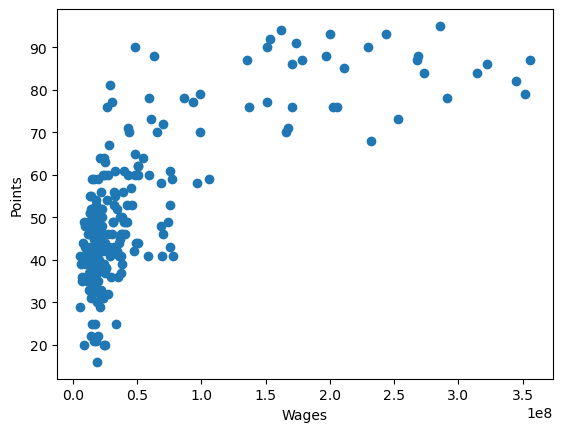

Correlation between Annual wages and points: 0.74


In [92]:
plt.scatter(x = merged_df['AnnualWages_EUR'], y = merged_df['Pts'])
plt.xlabel("Wages")
plt.ylabel("Points")
plt.show()
corr = merged_df["AnnualWages_EUR"].corr(merged_df["Pts"])
print(f"Correlation between Annual wages and points: {corr:.2f}")

/var/folders/83/_2b67r3s3sqcvq01cj080wsr0000gn/T/ipykernel_53148/69065423.py:23: UserWarning: The palette list has more values (225) than needed (4), which may not be intended.
  sns.scatterplot(


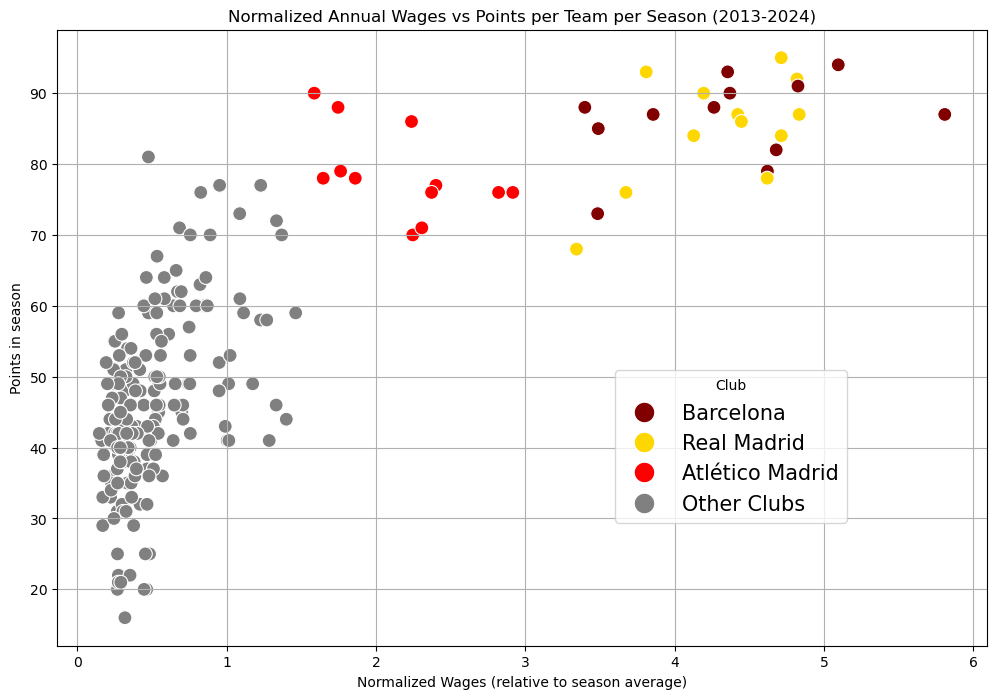

Correlation between normalized wages and points: 0.79


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Normalize wages by year
merged_df["norm_wages"] = merged_df.groupby("Season_x")["AnnualWages_EUR"].transform(lambda x: x / x.mean())

# Scatter plot
plt.figure(figsize=(12, 8))

# Default color
colors = ["gray"] * len(merged_df)

# Assign specific colors for top 3 clubs
for i, club in enumerate(merged_df["Club"]):
    if club == "Barcelona":
        colors[i] = "maroon"
    elif club == "Real Madrid":
        colors[i] = "gold"
    elif club == "Atlético Madrid":
        colors[i] = "red"

# Plot
sns.scatterplot(
    data=merged_df,
    x="norm_wages",
    y="Pts",
    hue=colors,
    palette=colors,
    legend=False,
    s=100
)
from matplotlib.lines import Line2D
leg_sz = 15
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Barcelona', markerfacecolor='maroon', markersize=leg_sz),
    Line2D([0], [0], marker='o', color='w', label='Real Madrid', markerfacecolor='gold', markersize=leg_sz),
    Line2D([0], [0], marker='o', color='w', label='Atlético Madrid', markerfacecolor='red', markersize=leg_sz),
    Line2D([0], [0], marker='o', color='w', label='Other Clubs', markerfacecolor='gray', markersize=leg_sz)
]
plt.legend(handles=legend_elements, fontsize = leg_sz, title="Club", loc = (.6, .2))
plt.xlabel("Normalized Wages (relative to season average)")
plt.ylabel("Points in season")
plt.title("Normalized Annual Wages vs Points per Team per Season (2013-2024)")
plt.grid(True)
plt.show()

# Calculate correlation between normalized wages and points
corr = merged_df["norm_wages"].corr(merged_df["Pts"])
print(f"Correlation between normalized wages and points: {corr:.2f}")




/var/folders/83/_2b67r3s3sqcvq01cj080wsr0000gn/T/ipykernel_53148/194298323.py:22: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(


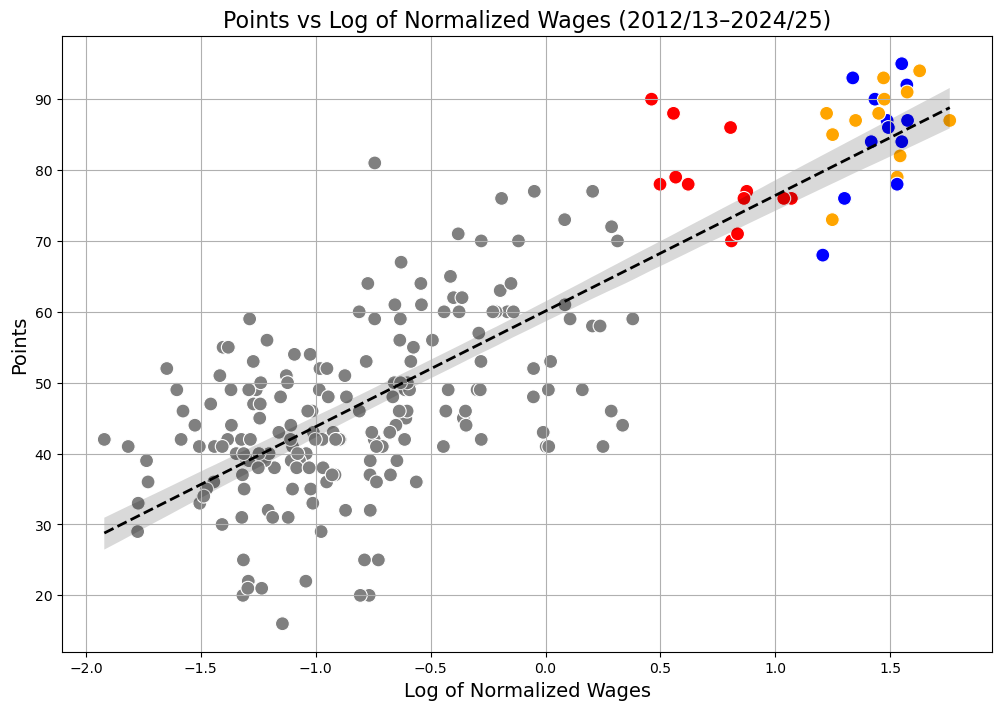

Correlation (log wages vs points): 0.82


In [79]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Log-transform the normalized wages
merged_df["log_wages"] = np.log(merged_df["norm_wages"])

# Assign colors based on club
def club_color(row):
    if row["Club"] == "Barcelona":
        return "orange"
    elif row["Club"] == "Real Madrid":
        return "blue"
    elif row["Club"] == "Atlético Madrid":
        return "red"
    else:
        return "grey"

merged_df["color"] = merged_df.apply(club_color, axis=1)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=merged_df,
    x="log_wages",
    y="Pts",
    hue="color",
    palette=merged_df["color"].unique(),
    s=100,
    legend=False
)

# Add regression line
sns.regplot(
    data=merged_df,
    x="log_wages",
    y="Pts",
    scatter=False,
    line_kws={"color": "black", "linewidth": 2, "linestyle": "--"}
)

plt.xlabel("Log of Normalized Wages", fontsize=14)
plt.ylabel("Points", fontsize=14)
plt.title("Points vs Log of Normalized Wages (2012/13–2024/25)", fontsize=16)
plt.grid(True)
plt.show()

# Optional: correlation
corr_log = merged_df["log_wages"].corr(merged_df["Pts"])
print(f"Correlation (log wages vs points): {corr_log:.2f}")


/var/folders/83/_2b67r3s3sqcvq01cj080wsr0000gn/T/ipykernel_53148/2079627970.py:22: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(


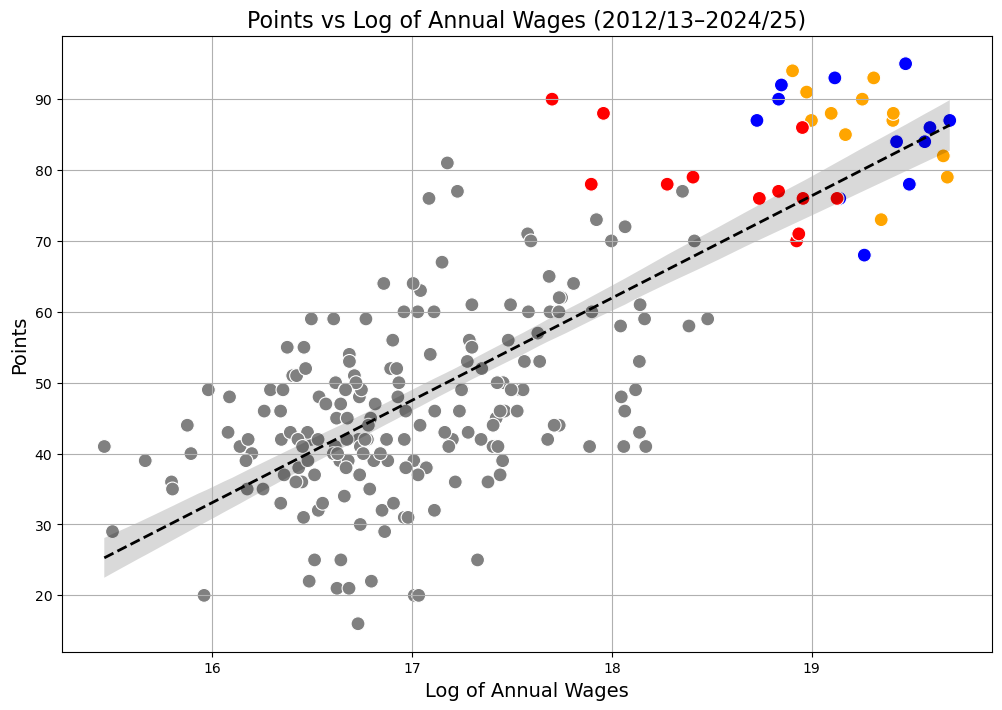

Correlation (log wages vs points): 0.82


In [91]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Log-transform the normalized wages
merged_df["log_Annwages"] = np.log(merged_df["AnnualWages_EUR"])

# Assign colors based on club
def club_color(row):
    if row["Club"] == "Barcelona":
        return "orange"
    elif row["Club"] == "Real Madrid":
        return "blue"
    elif row["Club"] == "Atlético Madrid":
        return "red"
    else:
        return "grey"

merged_df["color"] = merged_df.apply(club_color, axis=1)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=merged_df,
    x="log_Annwages",
    y="Pts",
    hue="color",
    palette=merged_df["color"].unique(),
    s=100,
    legend=False
)

# Add regression line
sns.regplot(
    data=merged_df,
    x="log_Annwages",
    y="Pts",
    scatter=False,
    line_kws={"color": "black", "linewidth": 2, "linestyle": "--"}
)

plt.xlabel("Log of Annual Wages", fontsize=14)
plt.ylabel("Points", fontsize=14)
plt.title("Points vs Log of Annual Wages (2012/13–2024/25)", fontsize=16)
plt.grid(True)
plt.show()

# Optional: correlation
corr_log = merged_df["log_wages"].corr(merged_df["Pts"])
print(f"Correlation (log wages vs points): {corr_log:.2f}")


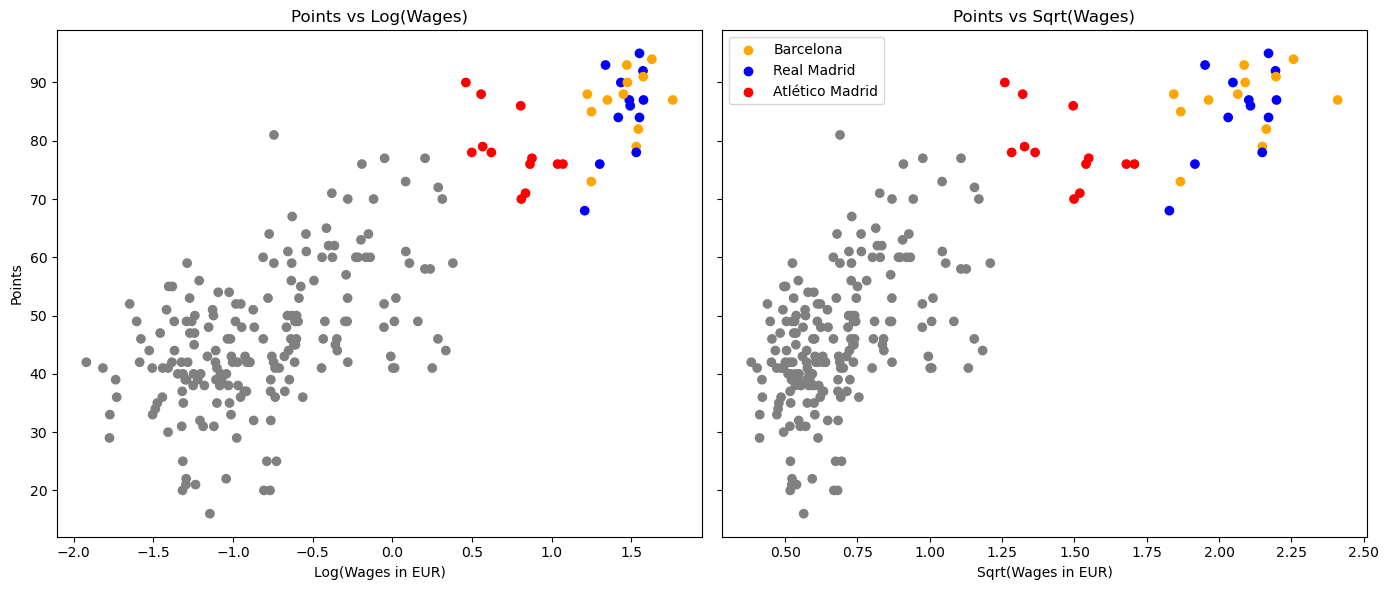

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming df has columns: 'wages_eur' (normalized or absolute) and 'Points'
df_plot = merged_df.copy()  # or your combined wages + standings dataframe

# Colors for the main teams
colors = df_plot['Club'].map({
    'Barcelona': 'orange',
    'Real Madrid': 'blue',
    'Atlético Madrid': 'red'
}).fillna('grey')

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 1. Log-transformed wages
axes[0].scatter(np.log(df_plot['norm_wages']), df_plot['Pts'], c=colors)
axes[0].set_xlabel('Log(Wages in EUR)')
axes[0].set_ylabel('Points')
axes[0].set_title('Points vs Log(Wages)')

# 2. Square-root-transformed wages
axes[1].scatter(np.sqrt(df_plot['norm_wages']), df_plot['Pts'], c=colors)
axes[1].set_xlabel('Sqrt(Wages in EUR)')
axes[1].set_title('Points vs Sqrt(Wages)')

# Optional: add a legend for the three teams
for club, color in zip(['Barcelona', 'Real Madrid', 'Atlético Madrid'], ['orange', 'blue', 'red']):
    axes[1].scatter([], [], color=color, label=club)
axes[1].legend()

plt.tight_layout()
plt.show()


/var/folders/83/_2b67r3s3sqcvq01cj080wsr0000gn/T/ipykernel_53148/1959234792.py:26: UserWarning: The palette list has more values (225) than needed (4), which may not be intended.
  sns.scatterplot(


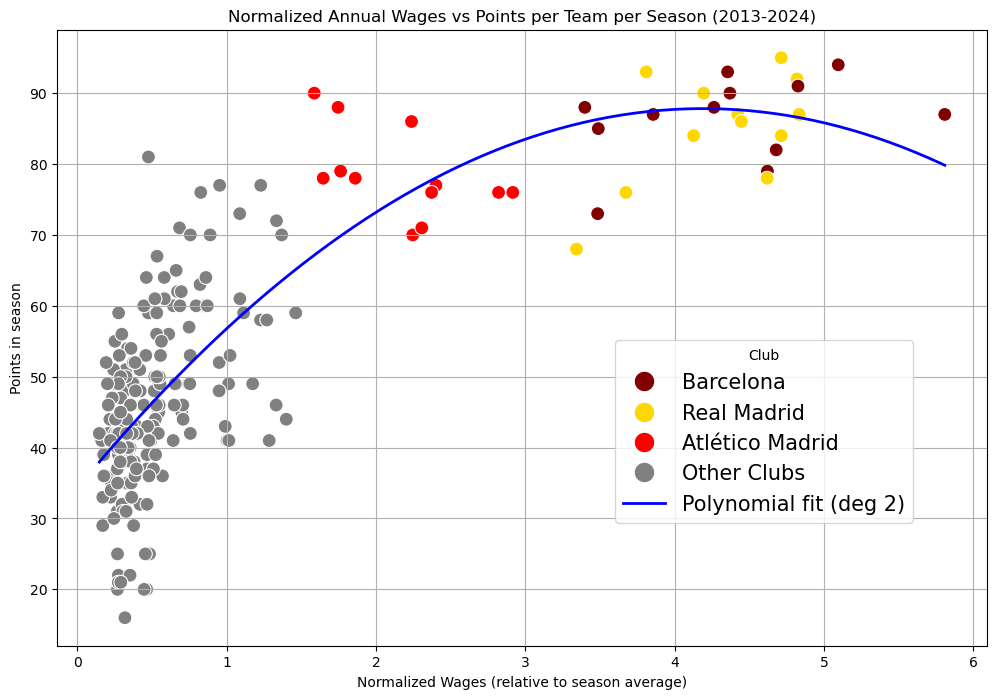

Correlation between normalized wages and points: 0.79


In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Normalize wages by year
merged_df["norm_wages"] = merged_df.groupby("Season_x")["AnnualWages_EUR"].transform(lambda x: x / x.mean())

# Scatter plot
plt.figure(figsize=(12, 8))

# Default color
colors = ["gray"] * len(merged_df)

# Assign specific colors for top 3 clubs
for i, club in enumerate(merged_df["Club"]):
    if club == "Barcelona":
        colors[i] = "maroon"
    elif club == "Real Madrid":
        colors[i] = "gold"
    elif club == "Atlético Madrid":
        colors[i] = "red"

# Plot scatter
sns.scatterplot(
    data=merged_df,
    x="norm_wages",
    y="Pts",
    hue=colors,
    palette=colors,
    legend=False,
    s=100
)

# Polynomial regression (degree 2)
X = merged_df["norm_wages"].values.reshape(-1, 1)
y = merged_df["Pts"].values

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# Sort X for smooth line
X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_plot = model.predict(poly.transform(X_plot))

plt.plot(X_plot, y_plot, color="blue", linewidth=2, label="Polynomial fit (deg 2)")

# Custom legend
from matplotlib.lines import Line2D
leg_sz = 15
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Barcelona', markerfacecolor='maroon', markersize=leg_sz),
    Line2D([0], [0], marker='o', color='w', label='Real Madrid', markerfacecolor='gold', markersize=leg_sz),
    Line2D([0], [0], marker='o', color='w', label='Atlético Madrid', markerfacecolor='red', markersize=leg_sz),
    Line2D([0], [0], marker='o', color='w', label='Other Clubs', markerfacecolor='gray', markersize=leg_sz),
    Line2D([0], [0], color='blue', lw=2, label='Polynomial fit (deg 2)')
]
plt.legend(handles=legend_elements, fontsize=leg_sz, title="Club", loc=(.6, .2))

plt.xlabel("Normalized Wages (relative to season average)")
plt.ylabel("Points in season")
plt.title("Normalized Annual Wages vs Points per Team per Season (2013-2024)")
plt.grid(True)
plt.show()

# Calculate correlation between normalized wages and points
corr = merged_df["norm_wages"].corr(merged_df["Pts"])
print(f"Correlation between normalized wages and points: {corr:.2f}")


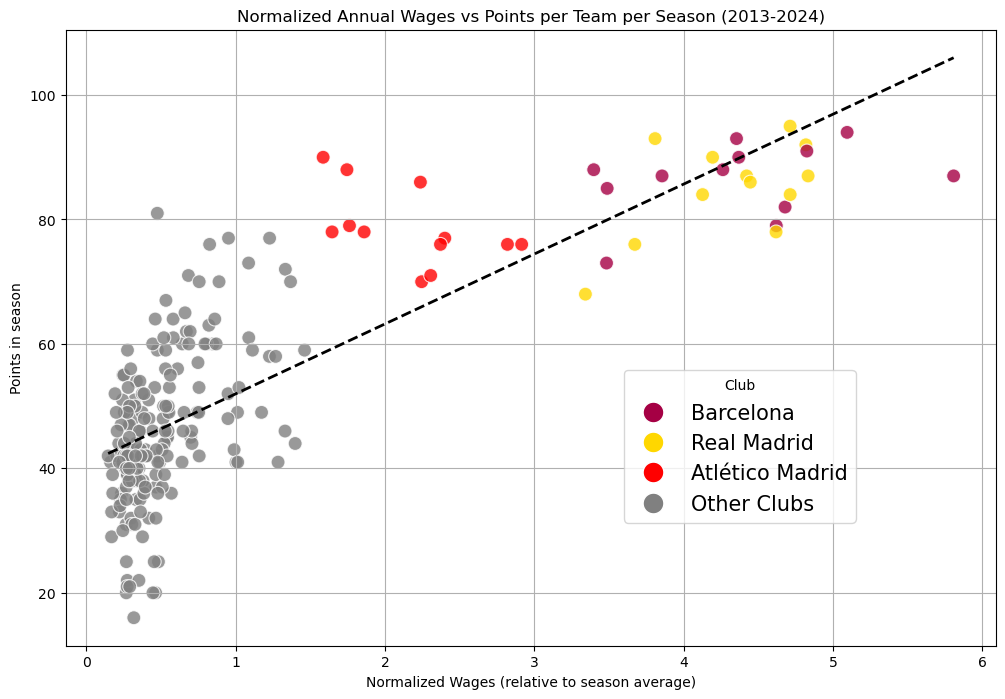

Correlation between normalized wages and points: 0.79


In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

# Normalize wages by year
merged_df["norm_wages"] = merged_df.groupby("Season_x")["AnnualWages_EUR"].transform(lambda x: x / x.mean())

# Scatter plot
plt.figure(figsize=(12, 8))

# Default color
colors = ["gray"] * len(merged_df)

# Assign specific colors for top 3 clubs
for i, club in enumerate(merged_df["Club"]):
    if club == "Barcelona":
        colors[i] = "#A50044"  # maroon
    elif club == "Real Madrid":
        colors[i] = "#FFD700"  # gold
    elif club == "Atlético Madrid":
        colors[i] = "#FF0000"  # red

# Plot scatter points
sns.scatterplot(
    data=merged_df,
    x="norm_wages",
    y="Pts",
    color=colors,
    s=100,
    alpha=0.8
)

# Add linear regression line (degree 1) as dotted black line
m, b = np.polyfit(merged_df["norm_wages"], merged_df["Pts"], 1)  # slope and intercept
x_vals = np.linspace(merged_df["norm_wages"].min(), merged_df["norm_wages"].max(), 100)
y_vals = m * x_vals + b
plt.plot(x_vals, y_vals, 'k--', linewidth=2, label=f'Linear fit: y = {m:.2f}x + {b:.2f}')

# Legend for clubs
leg_sz = 15
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Barcelona', markerfacecolor='#A50044', markersize=leg_sz),
    Line2D([0], [0], marker='o', color='w', label='Real Madrid', markerfacecolor='#FFD700', markersize=leg_sz),
    Line2D([0], [0], marker='o', color='w', label='Atlético Madrid', markerfacecolor='#FF0000', markersize=leg_sz),
    Line2D([0], [0], marker='o', color='w', label='Other Clubs', markerfacecolor='gray', markersize=leg_sz)
]
plt.legend(handles=legend_elements, fontsize=leg_sz, title="Club", loc=(0.6, 0.2))

plt.xlabel("Normalized Wages (relative to season average)")
plt.ylabel("Points in season")
plt.title("Normalized Annual Wages vs Points per Team per Season (2013-2024)")
plt.grid(True)

plt.show()

# Calculate correlation between normalized wages and points
corr = merged_df["norm_wages"].corr(merged_df["Pts"])
print(f"Correlation between normalized wages and points: {corr:.2f}")
